<a href="https://colab.research.google.com/github/karunyajayaraman/India-Port-Level-Export-Analytics/blob/main/India_Port_Level_Export_Analytics_2018_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **India Port Level Export Analytics (2018–2024)**

-------

# **📊Dataset information**
**Source :** India Data Portal/Directorate General of Commercial Intelligence and Statistics (DGCI&S)

**Location :** India

**Year/Timeline :** 2018-2024

**Domain:** Commerce / International Trade / Exports

**Dataset Name:** Exports at Principal Commodity Level

-------

#**🎯Business Problem Statement**

India's export performance varies across **years, states, and principal commodities**, making it important to understand the key factors driving export performance. A structured analysis is required to identify **major exporting states and commodities, yearly growth or decline, and the concentration of exports.**

This project aims to use historical export data to **analyze these patterns and generate meaningful business insights** that can support better understanding of India's export performance and opportunities.

--------

# **🎯Objectives**

1. **Analyze the overall export performance of India** across the available years
based on export value and quantity.
2. **Identify the top-performing principal commodities** based on their contribution to total export value.
3. **Analyze state-wise export performance** and identify the major exporting states.
4. **Examine yearly export trends** to identify growth, decline, and changes in export performance over time.
5. **Analyze the relationship between commodities and states** to identify which commodities contribute significantly to exports from different states.
6. **Identify major changes in commodity-wise export performance** across different years.
7. **Measure the contribution and concentration of major commodities and states** in India's overall exports.

---------


In [126]:
#Import the neccesary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime as dt


#**Dataset Access**

*   The original dataset is **100 MB**, which exceeds **GitHub’s 25 MB** browser upload limit.
*  Therefore, the complete dataset is stored in **Google Drive** without splitting or modifying it.
*   **Google Drive is mounted in Google Colab** to access the dataset directly for the capstone project.
*   This approach preserves **data integrity** and allows the complete dataset to be used for analysis and preprocessing.







In [2]:
#Mounting the Drive to colab notebook
from google.colab import drive
drive.mount('/content/drive')

#Read a CSV file from Drive
df = pd.read_csv("/content/drive/MyDrive/Data Analytics /Capstone Project - Exports at Principal Commodity Level /exports-at-principal-commodity-level.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Displaying the Dataframe
df

,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value
0,0,2018-01-01,Andhra Pradesh,28,Albania,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,82500,27451,1746880
1,1,2018-01-01,Andhra Pradesh,28,Albania,Visakhapatnam Sea,L5,"Aluminium, Products Of Aluminm",Ton,504,1185847,75463619
2,2,2018-01-01,Andhra Pradesh,28,Algeria,Apiic Building Product,F3,"Granit, Natrl Stone And Prodct",Kgs,1182000,620666,39497231
3,3,2018-01-01,Andhra Pradesh,28,Algeria,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,1782340,759041,48303027
4,4,2018-01-01,Andhra Pradesh,28,Algeria,Visakhapatnam Sea,J5,Ceramics And Allied Products,NaN,0,153958,9797426
...,...,...,...,...,...,...,...,...,...,...,...,...
6912487,6912487,2023-12-01,West Bengal,19,Zambia,Kolkata Sea,O3,Pumps Of All Types,NaN,0,1378,114727
6912488,6912488,2023-12-01,West Bengal,19,Zimbabwe,Kolkata Air,N6,Indl. Machnry For Dairy Etc,NaN,0,14459,1204125
6912489,6912489,2023-12-01,West Bengal,19,Zimbabwe,Kolkata Sea,R7,Jute Hessian,NaN,0,106177,8842324
6912490,6912490,2023-12-01,West Bengal,19,Zimbabwe,Kolkata Sea,R9,Other Jute Manufactures,NaN,0,36419,3032951


In [4]:
#Create a copy for original Dataframe
df_safe = df.copy()

# **Initial Inspect**

In [5]:
#Initial EDA
# Display first 5 rows
print('First 5 Rows\n')
df.head()

First 5 Rows



,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value
0,0,2018-01-01,Andhra Pradesh,28,Albania,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,82500,27451,1746880
1,1,2018-01-01,Andhra Pradesh,28,Albania,Visakhapatnam Sea,L5,"Aluminium, Products Of Aluminm",Ton,504,1185847,75463619
2,2,2018-01-01,Andhra Pradesh,28,Algeria,Apiic Building Product,F3,"Granit, Natrl Stone And Prodct",Kgs,1182000,620666,39497231
3,3,2018-01-01,Andhra Pradesh,28,Algeria,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,1782340,759041,48303027
4,4,2018-01-01,Andhra Pradesh,28,Algeria,Visakhapatnam Sea,J5,Ceramics And Allied Products,NaN,0,153958,9797426


In [6]:
#Display Random Data
print('Random 15 Rows\n')
df.sample(10)

Random 15 Rows



,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value
2268785,2268785,2023-04-01,Maharashtra,27,Libya,Nhava Sheva Sea,ZZ,Other Commodities,NaN,0,8215,673784
3897258,3897258,2021-07-01,Gujarat,24,U S A,Icd Sabarmati,B4,Sesame Seeds,Kgs,249005,413552,30820781
2595278,2595278,2020-05-01,Haryana,6,Australia,Icd Sonipat,S2,Carpet(Excl. Silk) Handmade,Sqm,167065,1245077,94202376
6820193,6820193,2023-12-01,Delhi,7,Colombia,Delhi Air,J6,Glass And Glassware,NaN,0,846,70476
2942904,2942904,2024-05-01,Kerala,32,South Sudan,Cochin Sea,O9,"Computer Hardware, Peripherals",NaN,0,110,9207
6847563,6847563,2023-12-01,Haryana,6,Saudi Arab,Icd Patli,M7,Machine Tools,NaN,0,16078,1338948
2086506,2086506,2021-04-01,Maharashtra,27,Denmark,Telegaon,Q3,"Manmade Yarn,Fabrics,Madeups",NaN,0,34693,2583677
4307823,4307823,2018-08-01,Tamil Nadu,33,Germany,Chennai Sea,L3,Iron And Steel,Ton,1,3885,270182
5332336,5332336,2018-10-01,Gujarat,24,Mexico,Mundra,P4,Telecom Instruments,NaN,0,68,5023
3331828,3331828,2021-06-01,Uttar Pradesh,9,U K,Cgml Dadri,H8,"Drug Formulations, Biologicals",Kgs,51791,840703,61840688


In [7]:
#shape of the DataFrame(Rows * Columns)
print(f'Rows * Columns : {df.shape}')
#df.shape

Rows * Columns : (6912492, 12)


In [8]:
#Column name of DataFrame(Index)
print(f'Column Names\n\n{df.columns}')
#df.columns

Column Names

Index(['id', 'date', 'state_name', 'state_code', 'country', 'port', 'pc_code',
       'commodity', 'units', 'quantity', 'dollars_value', 'inr_value'],
      dtype='object')


In [9]:
#check the Structure and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6912492 entries, 0 to 6912491
Data columns (total 12 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   id             int64 
 1   date           object
 2   state_name     object
 3   state_code     int64 
 4   country        object
 5   port           object
 6   pc_code        object
 7   commodity      object
 8   units          object
 9   quantity       int64 
 10  dollars_value  int64 
 11  inr_value      int64 
dtypes: int64(5), object(7)
memory usage: 632.9+ MB


**Data Quality Check**

In [10]:
#check the null Availability
print('Check the Missing values in each column')
df.isnull().sum()

Check the Missing values in each column


,0
id,0
date,0
state_name,0
state_code,0
country,0
port,0
pc_code,0
commodity,0
units,4468611
quantity,0


In [11]:
#check the duplicates
print(f'Number of duplicate Rows : {df.duplicated().sum()}')
#df.duplicated().sum()

Number of duplicate Rows : 0


In [12]:
#check the Dtypes
print("Data Types of Each Column")
df.dtypes

Data Types of Each Column


,0
id,int64
date,object
state_name,object
state_code,int64
country,object
port,object
pc_code,object
commodity,object
units,object
quantity,int64


In [13]:
#Show summary statistics for numeric columns
df.describe()

,id,state_code,quantity,dollars_value,inr_value
count,6.912492e+06,6.912492e+06,6.912492e+06,6.912492e+06,6.912492e+06
mean,3.456246e+06,2.197452e+01,6.441445e+04,3.579661e+05,2.724225e+07
std,1.995465e+06,1.036333e+01,3.720349e+06,5.306167e+06,4.074252e+08
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.728123e+06,9.000000e+00,0.000000e+00,2.153000e+03,1.622700e+05
50%,3.456246e+06,2.700000e+01,0.000000e+00,1.950200e+04,1.466100e+06
75%,5.184368e+06,2.900000e+01,3.900000e+01,9.976200e+04,7.535096e+06
max,6.912491e+06,9.900000e+01,7.620654e+09,1.449331e+09,1.192634e+11


In [14]:
#Check the number of unique counts
df.nunique()

,0
id,6912492
date,79
state_name,30
state_code,30
country,244
port,569
pc_code,168
commodity,168
units,5
quantity,208346


In [15]:
#check the unique value for 'units' column

#kgs - KiloGram
#tons - Tons
#Sqm - square meter
#Ltr - litre
#Nos - Not Otherwise Specified

df['units'].unique()

array(['Kgs', 'Ton', nan, 'Ltr', 'Nos', 'Sqm'], dtype=object)

# **Stage 2**

**Data Cleaning,Data Transformation and Feature Engineering**

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns

Treat outliers if required(optional)

Convert data types if needed

Data Transformation or Data Wrangling

Final EDA

In [16]:
df.isnull().sum()

,0
id,0
date,0
state_name,0
state_code,0
country,0
port,0
pc_code,0
commodity,0
units,4468611
quantity,0


# **Data Cleaning**

# **ID column**

**Check Duplicates & Missing values**


In [17]:
# Check Null Values & Duplicates in ID column

print('ID-Column\n')

print(f'Null Values : {df['id'].isnull().sum()}')
print(f'Duplicates : {df['id'].duplicated().sum()}')

ID-Column

Null Values : 0
Duplicates : 0


In [18]:
# Check Datatype of ID column

print(f'Datatype : {df['id'].dtypes}')

Datatype : int64


In [19]:
# Check Unique Values of ID column

print(f'Unique values : {df['id'].nunique()}')

Unique values : 6912492


In [20]:
# Check Value Counts in ID column

print(f'Value Counts : {df.id.value_counts().sum()}')

Value Counts : 6912492


# **Data Transformation**


**DataType-Conversion**

In [21]:
# ID Column should be STRING - Convert Dtype int64 to str

df['id'] = df['id'].astype(str)
print(f'Data Type of ID : {df['id'].dtypes}')

Data Type of ID : object


# **Date column**
**Check Datatype / Value Count**


In [22]:
# Check Datatype

print('Date-Column\n')
print(f'Datatype : {df['date'].dtypes}')    #Date is currently stored as text

Date-Column

Datatype : object


In [23]:
# Check value count of Date column

print(f'Value Counts : {df.date.value_counts().sum()}')  #matches total records

Value Counts : 6912492


# **Data Transformation**

**DataType-Conversion**

In [24]:
#convert date Dtype as datetime using pd.to_datetime

df['date'] = pd.to_datetime(df['date'])
print(f'Data Type of Date : {df['date'].dtypes}')

Data Type of Date : datetime64[ns]


# **State_name**
**Check Duplicates & Missing values**

In [25]:
# Check Datatype/Null Values

print('State_Name Column\n')

print(f'Datatype : {df['state_name'].dtypes}')
print(f'Null Values : {df['state_name'].isnull().sum()}')

State_Name Column

Datatype : object
Null Values : 0


In [26]:
#Check Number of unique counts

print('\nNumber of Unique Values:\n')
df['state_name'].nunique()


Number of Unique Values:



30

In [27]:
# Check unique value

print('\nUnique Values:\n')
df['state_name'].unique()


Unique Values:



array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh',
       'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra',
       'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'Various States', 'West Bengal',
       'Jammu And Kashmir', 'Manipur', 'Jharkhand', 'Sikkim'],
      dtype=object)

In [28]:
# check value_counts of state name

print('\nValue Counts:\n')
df['state_name'].value_counts().reset_index()


Value Counts:



,state_name,count
0,Maharashtra,1406584
1,Gujarat,1103124
2,Tamil Nadu,1090166
3,Delhi,694342
4,Karnataka,412865
5,Uttar Pradesh,388880
6,Haryana,317580
7,West Bengal,296353
8,Punjab,272961
9,Kerala,228291


In [29]:
#Checked the "Various states" counts

df.loc[df['state_name'] == 'Various States', ['state_name','state_code']].value_counts().reset_index()

,state_name,state_code,count
0,Various States,99,3767


#**State_code**

**Check DataType, Unique values, value count**

In [30]:
# Check Datatype

print('State_Code Column\n')

print(f'Datatype : {df['state_code'].dtypes}')

State_Code Column

Datatype : int64


In [31]:
#check the unique values of the state code

print('Unique Values \n')
df['state_code'].unique()

Unique Values 



array([28, 18, 10,  4, 22,  7, 30, 24,  6,  2, 29, 32, 23, 27, 17, 21, 34,
        3,  8, 33, 36, 16,  9,  5, 99, 19,  1, 14, 20, 11])

In [32]:
#check the counts of each state code

df['state_code'].value_counts().reset_index()

,state_code,count
0,27,1406584
1,24,1103124
2,33,1090166
3,7,694342
4,29,412865
5,9,388880
6,6,317580
7,19,296353
8,3,272961
9,32,228291


In [33]:
#check the number of unique codes available in the state code column

print(f'Number of Unique code : {df['state_code'].nunique()}')

Number of Unique code : 30


# **Data Transformation**

**DataType-Conversion**

In [34]:
#Convert state_code Dtype as 'str'- Because this is a state identifier, not a value used for mathematical calculations

df['state_code'] = df['state_code'].astype(str)

In [35]:
df['state_code'].dtypes

dtype('O')

# **Country**
**Check DataType, Unique Values, Value Counts**

In [36]:
#check the Null count

print(f'Datatype : {df['country'].dtypes}')

Datatype : object


In [37]:
#check the unique values of the column
print('Unique Values : \n')
df['country'].unique()

Unique Values : 



array(['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Baharain Is',
       'Bangladesh Pr', 'Barbados', 'Belgium', 'Benin', 'Bolivia',
       'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia',
       'Cameroon', 'Canada', 'Cape Verde Is', 'Chad', 'Chile',
       'China P Rp', 'Colombia', 'Congo D. Rep.', 'Congo P Rep',
       'Costa Rica', "Cote D' Ivoire", 'Croatia', 'Cuba', 'Cyprus',
       'Czech Republic', 'Denmark', 'Djibouti', 'Dominic Rep', 'Ecuador',
       'Egypt A Rp', 'El Salvador', 'Estonia', 'Ethiopia', 'Finland',
       'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Guinea', 'Guinea Bissau', 'Haiti', 'Honduras', 'Hong Kong',
       'Hungary', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel',
       'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya',
       'Korea Rp', 'Kuwait', 'Kyrghyzstan', 'Lebanon', 'Lesotho',
       'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Macedoni

In [38]:
#check the number of country's available in the column

print(f'Number of Unique Countrys : {df['country'].nunique()}')

Number of Unique Countrys : 244


In [39]:
#check the value counts of each country

df['country'].value_counts().reset_index()

,country,count
0,U S A,290953
1,U Arab Emts,221030
2,U K,189904
3,Germany,164616
4,Australia,152879
...,...,...
239,Heard Macdonald,3
240,Svallbard And Jan Mayen,2
241,Serbia Montngro,2
242,Pacific Is,1


# **Port**
**Check DataType, Unique Values, Value count**

In [40]:
#check the Null count

print(f'Datatype : {df['port'].dtypes}')

Datatype : object


In [41]:
#check the unique values of the column

print('Unique Values : \n')
df['port'].unique()

Unique Values : 



array(['Krishnapatnam', 'Visakhapatnam Sea', 'Apiic Building Product',
       'Visakhapatnam Spl Economic Zon', 'Ap Industrial Infra Ltd Ph',
       'Apache Footware Nellore', 'Appiic Multi Prod Sez Vizag Dc',
       'Devi S Laboratories Ltd', 'Hetero Infra Sez Nakkapalli Ap',
       'Mas Fabric Park (India) Pvt Lt', 'Ramki Pharma City (India) Pvt',
       'Brandix Indiaapparel Pvt Ltd', 'Sri City Pvt Ltd', 'Kakinada Sea',
       'Apiic Limited(Naidupeta)', 'Gangavaram Port',
       'Sundew Properties It Sez Ap', 'Shantha Biotech Sez Vizag Dc',
       'Vishakhapatnam Airport', 'Apiic Sez Aerospace, Vizag',
       'Dlf Comm Developers Vizag', "Dr. Reddy'S Lab. Vizag",
       'Cmc Ltd, Vizag', 'Karimganj Steamerghat', 'Mankachar',
       'Sutarkandi', 'Icd Guwahati(Amin Gaon)', 'Sheuabazar',
       'Raxaul Land', 'Bairgania', 'Jogbani', 'L C S Khunwa',
       'Nirmali/Kanauli', 'Sonbarsa', 'Rgtech Park Dca-I,Chandigarh',
       'Icd Raipur', 'Delhi (Icd)', 'Delhi Air', 'Cfs Patparganj',


In [42]:
#check the number of Port's available in the column

print(f'Number of Unique Port : {df['port'].nunique()}')

Number of Unique Port : 569


In [43]:
#check the value_counts available in the column

df['port'].value_counts().reset_index()

,port,count
0,Nhava Sheva Sea,685806
1,Mumbai Air,423126
2,Delhi Air,420245
3,Mundra,381210
4,Chennai Sea,285490
...,...,...
564,"Gurgaon Infospace Ltd. Sez, Du",1
565,"M/S E Complex Pvt.Ltd., Rampur",1
566,Loma It Part Dev Ghansoli,1
567,Milestone Buildcon Sez,1


# **pc_code**

**Check DataType, Unique Values, Value count**

In [44]:
#check the Null count

print(f'Datatype : {df['pc_code'].dtypes}')

Datatype : object


In [45]:
#check the unique values of the column

print('Unique Values : \n')
df['pc_code'].unique()

Unique Values : 



array(['F3', 'L5', 'J5', 'I7', 'I3', 'H8', 'G2', 'L3', 'H5', 'Q6', 'I4',
       'H9', 'I2', 'ZZ', 'N5', 'F4', 'N6', 'Q8', 'A2', 'S1', 'O1', 'L4',
       'E7', 'F6', 'J9', 'F9', 'F2', 'O6', 'S4', 'P8', 'P9', 'P7', 'A4',
       'P3', 'D5', 'K8', 'M5', 'A8', 'N2', 'G5', 'N7', 'M3', 'J4', 'I5',
       'K4', 'J1', 'R2', 'B1', 'H1', 'P1', 'K5', 'K1', 'P2', 'N4', 'M7',
       'N9', 'M8', 'D7', 'L6', 'O9', 'B2', 'D1', 'N1', 'J6', 'R7', 'R9',
       'F8', 'Q3', 'M2', 'A1', 'E8', 'J2', 'M6', 'I9', 'O3', 'D4', 'K7',
       'C7', 'E6', 'H3', 'K6', 'K9', 'L1', 'P4', 'C9', 'D2', 'E2', 'H7',
       'R1', 'O7', 'H4', 'A6', 'O4', 'I1', 'C6', 'E4', 'J7', 'Q9', 'Q5',
       'B5', 'F1', 'S6', 'C8', 'I8', 'S2', 'C2', 'D3', 'N3', 'H6', 'M4',
       'I6', 'H2', 'G9', 'J3', 'R3', 'R5', 'L7', 'G3', 'G1', 'P6', 'O5',
       'Q2', 'E5', 'L8', 'N8', 'M9', 'B9', 'L2', 'O2', 'P5', 'Q7', 'C4',
       'L9', 'A9', 'O8', 'A5', 'M1', 'B6', 'A7', 'C5', 'E9', 'B7', 'A3',
       'B4', 'C3', 'F5', 'B8', 'R8', 'G4', 'S3', 'G

In [46]:
#check the number of unique PC_Code available in the column

print(f'\nNumber of Unique PC_Code : {df['pc_code'].nunique()}')


Number of Unique PC_Code : 168


In [47]:
#check the value_counts available in the column

df['pc_code'].value_counts().reset_index()

,pc_code,count
0,L4,201592
1,N6,186276
2,N4,169268
3,ZZ,161714
4,O1,153684
...,...,...
163,R5,372
164,G6,331
165,D9,327
166,Q1,181


# **Commodity**

**Check DataType, Unique Values, Value count**

In [48]:
#check the Null count

print(f'Datatype : {df['commodity'].dtypes}')

Datatype : object


In [49]:
#check the unique values of the column

print('Unique Values : \n')
df['commodity'].unique()

Unique Values : 



array(['Granit, Natrl Stone And Prodct', 'Aluminium, Products Of Aluminm',
       'Ceramics And Allied Products', 'Residul Chemicl And Alled Prod',
       'Organic Chemicals', 'Drug Formulations, Biologicals',
       'Footwear Of Leather', 'Iron And Steel',
       'Bulk Drugs, Drug Intermediates', 'Rmg Cotton Incl Accessories',
       'Other Miscellaenious Chemicals', 'Agro Chemicals',
       'Inorganic Chemicals', 'Other Commodities', 'Ic Engines And Parts',
       'Processed Minerals', 'Indl. Machnry For Dairy Etc',
       'Rmg Manmade Fibres', 'Coffee', 'Handcrfs(Excl.Handmade Crpts)',
       'Other Misc. Engineering Items', 'Products Of Iron And Steel',
       'Marine Products', 'Other Crude Minerals',
       'Paper, Paper Board And Product', 'Leather Goods',
       'Bulk Minerals And Ores', 'Railwy Trnsprt Equipmnts, Prts',
       'Cotton Raw Incld. Waste', 'Cotton Fabrics, Madeups Etc.',
       'Oth Txtl Yrn, Fbric Mdup Artcl', 'Cotton Yarn',
       'Rice(Other Than Basmoti)', 'E

In [50]:
#check the number of unique Commodity available in the column

print(f'\nNumber of Unique Commodity : {df['commodity'].nunique()}')


Number of Unique Commodity : 168


In [51]:
#check the value_counts available in the column

df['commodity'].value_counts().reset_index()

,commodity,count
0,Products Of Iron And Steel,201592
1,Indl. Machnry For Dairy Etc,186276
2,Electric Machinery And Equipme,169268
3,Other Commodities,161714
4,Other Misc. Engineering Items,153684
...,...,...
163,"Jute, Raw",372
164,Gold,331
165,Other Meat,327
166,"Silk,Raw",181


# **Units**
**Check DataType, Unique Values, Value count**

In [52]:
#check the Datatype

print(f'DataType of Units column : {df['units'].dtypes}')

DataType of Units column : object


In [53]:
#check unique values

print(f'Unique Values : {df['units'].unique()}')

Unique Values : ['Kgs' 'Ton' nan 'Ltr' 'Nos' 'Sqm']


In [54]:
#check number of counts of units

print("Value_counts: \n")
df['units'].value_counts(dropna = False).reset_index()

Value_counts: 



,units,count
0,NaN,4468611
1,Kgs,1497945
2,Ton,793376
3,Nos,85063
4,Sqm,55495
5,Ltr,12002


In [55]:
# Check Null Values

print(f'Number of Null Values : {df['units'].isnull().sum()}')  #Too large null count

Number of Null Values : 4468611


**Handle the missing value**

In [56]:
# Check the Mode Value

df['units'].mode()[0]

'Kgs'

This gives the number of records where both units is NULL & quantity = 0

Total records: 6,912,492

Missing units: 4,468,611

Null value percentage - 64.65%

In [57]:
# Check how many rows have BOTH missing units (NaN) AND quantity = 0

df.loc[(df['quantity'] == 0) & (df['units'].isnull()), ['quantity', 'units']].shape

#For all records where units is missing (NaN), the corresponding quantity is 0.


(4468611, 2)

**Data-cleaning conclusion:**

The units column contains **4,468,611** missing values **(64.65%)**.

Further analysis shows that all these missing-unit records have quantity = 0. Since these records have zero quantity, the missing units values have **limited impact on the statistical analysis**.

The missing values will be imputed using the **mode value (KGS)** to maintain consistency and enable further analysis.

In [58]:
# Imputation by MODE value

df['units'] = df['units'].fillna(df['units'].mode()[0])

In [59]:
# Check Null values - After Imputation

df['units'].isnull().sum()

np.int64(0)

In [60]:
# Check the Value Counts

df['units'].value_counts(dropna = False).reset_index()

,units,count
0,Kgs,5966556
1,Ton,793376
2,Nos,85063
3,Sqm,55495
4,Ltr,12002


# **Quantity**

**Check DataType/Missing values/Descriptive Statistics**

In [61]:
#check the Datatype

print('Quantity Column\n')

print(f'DataType of Quantity : {df['quantity'].dtypes}')

Quantity Column

DataType of Quantity : int64


In [62]:
# check the Null values

print(f"Null Values : {df['quantity'].isnull().sum()}")

Null Values : 0


In [63]:
# Check Descriptive Statistics

print(f"Summary Statistics \n {df['quantity'].describe().reset_index()}")


Summary Statistics 
    index      quantity
0  count  6.912492e+06
1   mean  6.441445e+04
2    std  3.720349e+06
3    min  0.000000e+00
4    25%  0.000000e+00
5    50%  0.000000e+00
6    75%  3.900000e+01
7    max  7.620654e+09


# **Dollars_value**

**Check Datatype / Missing values / Descriptive statistics**

In [64]:
print('Dollars_Value Column\n')

print(f"Datatype : {df['dollars_value'].dtypes}")
print(f"Null Values : {df['dollars_value'].isnull().sum()}")

Dollars_Value Column

Datatype : int64
Null Values : 0


In [65]:
# check Descriptive statistics

print('\nSummary Statistics:\n')
df['dollars_value'].describe().reset_index()


Summary Statistics:



,index,dollars_value
0,count,6.912492e+06
1,mean,3.579661e+05
2,std,5.306167e+06
3,min,0.000000e+00
4,25%,2.153000e+03
5,50%,1.950200e+04
6,75%,9.976200e+04
7,max,1.449331e+09


# **INR_value**

**Check Datatype & Missing values**

In [66]:
print('INR_Value Column\n')

print(f"Datatype : {df['inr_value'].dtypes}")
print(f"Null Values : {df['inr_value'].isnull().sum()}")

INR_Value Column

Datatype : int64
Null Values : 0


In [67]:
# check Descriptive statistics

print('\nSummary Statistics:\n')
print(df['inr_value'].describe())


Summary Statistics:

count    6.912492e+06
mean     2.724225e+07
std      4.074252e+08
min      1.000000e+00
25%      1.622700e+05
50%      1.466100e+06
75%      7.535096e+06
max      1.192634e+11
Name: inr_value, dtype: float64


# **Data Transformation**
*   column-name standardization

In [68]:
df.columns

Index(['id', 'date', 'state_name', 'state_code', 'country', 'port', 'pc_code',
       'commodity', 'units', 'quantity', 'dollars_value', 'inr_value'],
      dtype='object')

In [69]:
#column name renaming

df.rename(columns={'id': 'ID',
                   'date':'Date',
                   'state_name':'State_Name',
                   'state_code':'State_Code',
                   'country':'Country',
                   'port':'Port',
                   'pc_code':'PC_Code',
                   'commodity':'Commodity',
                   'units':'Units',
                   'quantity':'Quantity',
                   'dollars_value':'Dollars_Value',
                   'inr_value':'INR_Value'
                    }, inplace=True)

In [70]:
df.columns

Index(['ID', 'Date', 'State_Name', 'State_Code', 'Country', 'Port', 'PC_Code',
       'Commodity', 'Units', 'Quantity', 'Dollars_Value', 'INR_Value'],
      dtype='object')

# **Feature Engineering**

In [71]:
df.dtypes

,0
ID,object
Date,datetime64[ns]
State_Name,object
State_Code,object
Country,object
Port,object
PC_Code,object
Commodity,object
Units,object
Quantity,int64


In [72]:
print(df['Date'].head())

df['Date'].unique()[:10]

0   2018-01-01
1   2018-01-01
2   2018-01-01
3   2018-01-01
4   2018-01-01
Name: Date, dtype: datetime64[ns]


<DatetimeArray>
['2018-01-01 00:00:00', '2019-01-01 00:00:00', '2020-01-01 00:00:00',
 '2021-01-01 00:00:00', '2022-01-01 00:00:00', '2023-01-01 00:00:00',
 '2024-01-01 00:00:00', '2018-02-01 00:00:00', '2019-02-01 00:00:00',
 '2020-02-01 00:00:00']
Length: 10, dtype: datetime64[ns]

**Extract YEAR**

In [73]:
# Extract YEAR from Date Column

df['year'] = df['Date'].dt.year

In [74]:
# Check Null Values

df['year'].isnull().sum()

np.int64(0)

In [75]:
# Check the Unique year value

df['year'].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype=int32)

**Extract MONTH**

In [76]:
# Extract MONTH from Date Column

df['month'] = df['Date'].dt.month

In [77]:
# Check Null Values

df['month'].isnull().sum()

np.int64(0)

**Extract MONTH Name**

In [78]:
# Extract MONTH Name from Date Column

df['month_name'] = df['Date'].dt.strftime('%b')

In [79]:
# Check Null Values

df['month_name'].isnull().sum()

np.int64(0)

In [80]:
df[['Date', 'month_name']].head()

,Date,month_name
0,2018-01-01,Jan
1,2018-01-01,Jan
2,2018-01-01,Jan
3,2018-01-01,Jan
4,2018-01-01,Jan



# **Data Transformation**
*   column-name standardization




In [81]:
# check the column name of feature-engineered columns

df[['year', 'month', 'month_name']].columns

Index(['year', 'month', 'month_name'], dtype='object')

In [82]:
#column name renaming

df.rename(columns={'year' : 'Year',
                   'month' : 'Month',
                   'month_name' : 'Month_Name'},inplace = True)

In [83]:
# Check after column name renaming

df.columns

Index(['ID', 'Date', 'State_Name', 'State_Code', 'Country', 'Port', 'PC_Code',
       'Commodity', 'Units', 'Quantity', 'Dollars_Value', 'INR_Value', 'Year',
       'Month', 'Month_Name'],
      dtype='object')

# **Final EDA**

**1.** **Dataset shape**





In [84]:
df.shape

(6912492, 15)

**2. Column names**

In [85]:
df.columns

Index(['ID', 'Date', 'State_Name', 'State_Code', 'Country', 'Port', 'PC_Code',
       'Commodity', 'Units', 'Quantity', 'Dollars_Value', 'INR_Value', 'Year',
       'Month', 'Month_Name'],
      dtype='object')

**3. DataTypes**

In [86]:
df.dtypes

,0
ID,object
Date,datetime64[ns]
State_Name,object
State_Code,object
Country,object
Port,object
PC_Code,object
Commodity,object
Units,object
Quantity,int64


**4. Missing values**

In [87]:
df.isnull().sum().reset_index()

,index,0
0,ID,0
1,Date,0
2,State_Name,0
3,State_Code,0
4,Country,0
5,Port,0
6,PC_Code,0
7,Commodity,0
8,Units,0
9,Quantity,0


**5. Duplicated Records**

In [88]:
df.duplicated().sum()

np.int64(0)

**6. Overall Check**

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6912492 entries, 0 to 6912491
Data columns (total 15 columns):
 #   Column         Dtype         
---  ------         -----         
 0   ID             object        
 1   Date           datetime64[ns]
 2   State_Name     object        
 3   State_Code     object        
 4   Country        object        
 5   Port           object        
 6   PC_Code        object        
 7   Commodity      object        
 8   Units          object        
 9   Quantity       int64         
 10  Dollars_Value  int64         
 11  INR_Value      int64         
 12  Year           int32         
 13  Month          int32         
 14  Month_Name     object        
dtypes: datetime64[ns](1), int32(2), int64(3), object(9)
memory usage: 738.3+ MB


**7.Descriptive statistics**

In [90]:
df.describe()

,Date,Quantity,Dollars_Value,INR_Value,Year,Month
count,6912492,6.912492e+06,6.912492e+06,6.912492e+06,6.912492e+06,6.912492e+06
mean,2021-05-02 16:10:48.178863872,6.441445e+04,3.579661e+05,2.724225e+07,2.020892e+03,6.325193e+00
min,2018-01-01 00:00:00,0.000000e+00,0.000000e+00,1.000000e+00,2.018000e+03,1.000000e+00
25%,2019-09-01 00:00:00,0.000000e+00,2.153000e+03,1.622700e+05,2.019000e+03,3.000000e+00
50%,2021-06-01 00:00:00,0.000000e+00,1.950200e+04,1.466100e+06,2.021000e+03,6.000000e+00
75%,2023-01-01 00:00:00,3.900000e+01,9.976200e+04,7.535096e+06,2.023000e+03,9.000000e+00
max,2024-07-01 00:00:00,7.620654e+09,1.449331e+09,1.192634e+11,2.024000e+03,1.200000e+01
std,NaN,3.720349e+06,5.306167e+06,4.074252e+08,1.924536e+00,3.429835e+00


In [91]:
df.head()

,ID,Date,State_Name,State_Code,Country,Port,PC_Code,Commodity,Units,Quantity,Dollars_Value,INR_Value,Year,Month,Month_Name
0,0,2018-01-01,Andhra Pradesh,28,Albania,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,82500,27451,1746880,2018,1,Jan
1,1,2018-01-01,Andhra Pradesh,28,Albania,Visakhapatnam Sea,L5,"Aluminium, Products Of Aluminm",Ton,504,1185847,75463619,2018,1,Jan
2,2,2018-01-01,Andhra Pradesh,28,Algeria,Apiic Building Product,F3,"Granit, Natrl Stone And Prodct",Kgs,1182000,620666,39497231,2018,1,Jan
3,3,2018-01-01,Andhra Pradesh,28,Algeria,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,1782340,759041,48303027,2018,1,Jan
4,4,2018-01-01,Andhra Pradesh,28,Algeria,Visakhapatnam Sea,J5,Ceramics And Allied Products,Kgs,0,153958,9797426,2018,1,Jan


**Stage 2** was completed by performing data cleaning, missing-value handling, duplicate checks, data-type conversion, column-name standardization, data transformation, and feature engineering. The cleaned dataset is now prepared for further statistical analysis and exploratory data analysis.

# **Stage 3**

# **Statistical analysis for the Column - Quantity / Dollars_Value / INR_Value**

###**Measure of Central Tendency**

In [92]:
# MEASURE OF CENTRAL TENDENCY

cols = ['Quantity', 'Dollars_Value', 'INR_Value']

#summary table
summary_table = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Mode': df[cols].mode().iloc[0]
})

# Display the table
print("MEASURE OF CENTRAL TENDENCY\n\n", summary_table)

MEASURE OF CENTRAL TENDENCY

                        Mean     Median  Mode
Quantity       6.441445e+04        0.0     0
Dollars_Value  3.579661e+05    19502.0     1
INR_Value      2.724225e+07  1466100.0    82


**Central Tendency - Chart**

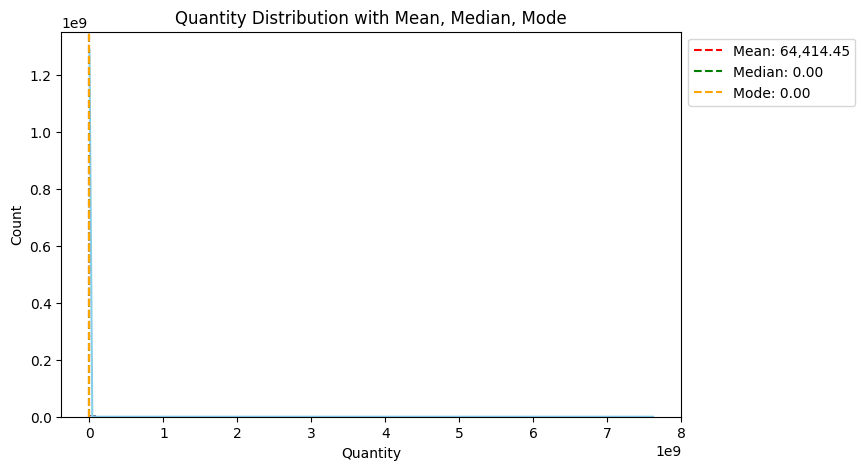

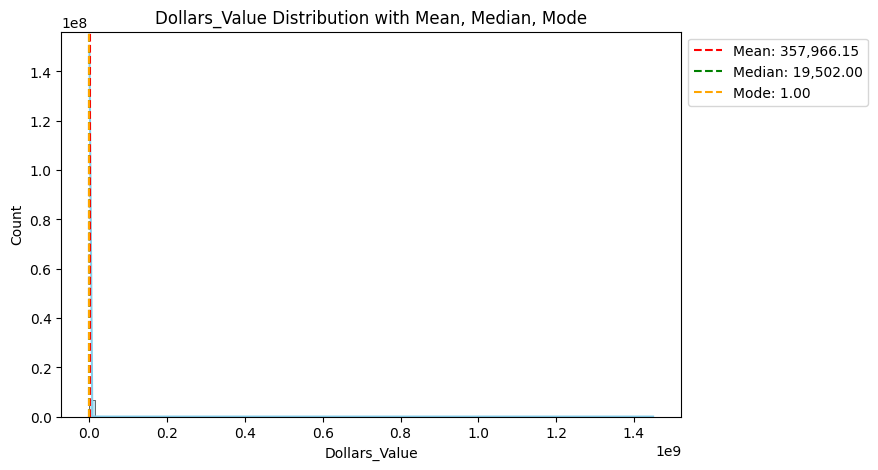

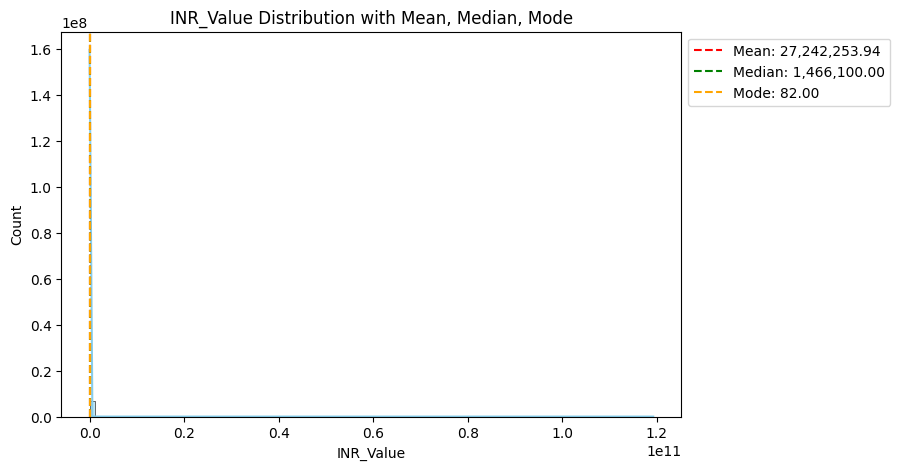

In [93]:
# Histogram - Mean/Meadian/Mode

for col in cols:

    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=100,kde=True,color='skyblue')

    plt.axvline(mean_val, color='red',linestyle='--',label=f'Mean: {mean_val:,.2f}')

    plt.axvline(median_val, color='green',linestyle='--',label=f'Median: {median_val:,.2f}')

    plt.axvline(mode_val, color='orange',linestyle='--',label=f'Mode: {mode_val:,.2f}')

    plt.title(f'{col} Distribution with Mean, Median, Mode')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.show()

**Interpretation of Measure of Central Tendency**

**Quantity:**

The mean quantity is approximately **64,414**, while both the median and mode are 0. This indicates that zero-quantity records are very frequent, and a relatively small number of records with extremely large quantities are pulling the mean upward. Therefore, the mean is not representative of the typical quantity in this dataset.

**Dollars_Value:**

The mean export value is approximately **357,966** , while the **median is 19,502 and the mode is 1** . The large difference between the mean and median indicates a **strong right-skewed distribution**, where a small number of very high-value exports increase the average.

**INR_Value:**

The mean export value is approximately **₹27.24 million**, compared with a **median of ₹1.47 million and a mode of ₹82**. The substantially higher mean indicates that the distribution is strongly right-skewed, influenced by a relatively **small number of high-value export transactions.**

###**Log-Transformed Visualization:(Central Tendency)**

A **log-transformed visualization** is useful when your data is highly skewed, especially when a few values are extremely large compared with most observations.

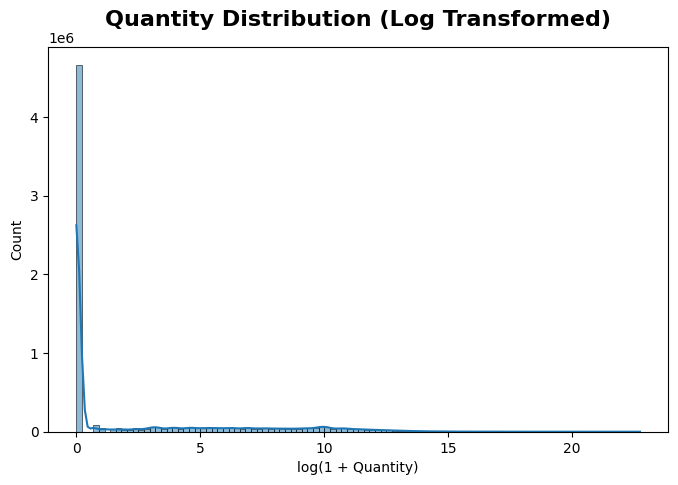

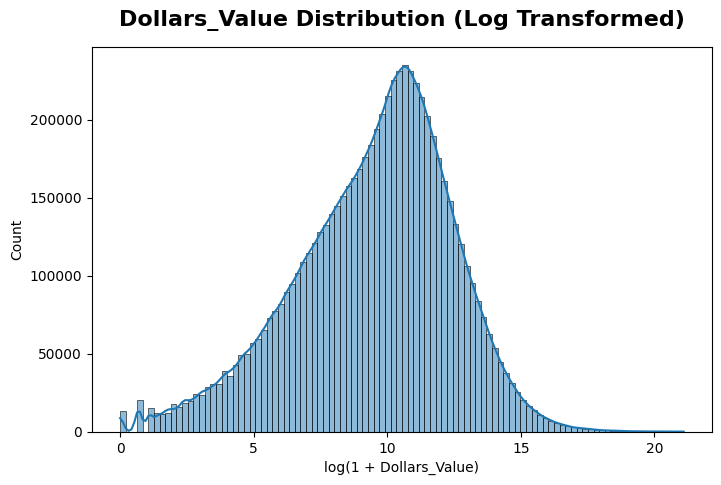

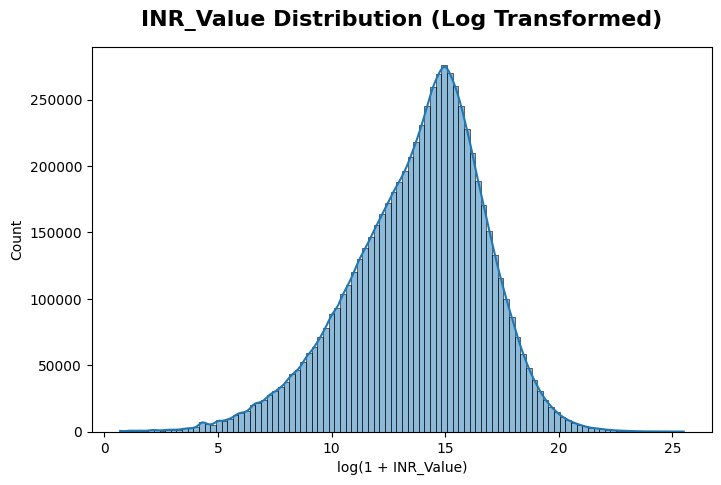

In [94]:
#create a log-transformed visualization
# Log-transformed distribution → makes the underlying distribution easier to interpret
for col in cols:

    plt.figure(figsize=(8,5))

    sns.histplot(np.log1p(df[col]),kde=True, bins=100)

    plt.title(f'{col} Distribution (Log Transformed)',fontsize=16,fontweight='bold',pad=15)
    plt.xlabel(f'log(1 + {col})')
    plt.ylabel('Count')

    plt.show()

**Interpretation of Log Transformed**

**Quantity (Log Transformed):**
Even after log transformation, the quantity distribution remains highly skewed towards zero, indicating a significant number of transactions with very small or zero quantities.

**Dollars_Value (Log Transformed):**
The log transformation successfully reduced the skewness, resulting in a more normalized, bell-shaped distribution centered around a specific range, making it easier to analyze typical export values.

**INR_Value (Log Transformed):**
Similar to 'Dollars_Value', the 'INR_Value' also shows a more normalized distribution after log transformation, suggesting that the transformation is effective in handling the extreme values present in the original data.

The log transformation helps to mitigate the impact of extreme outliers and large values, allowing for a better understanding of the underlying patterns and central tendency for 'Dollars_Value' and 'INR_Value' specifically.

### **Measure of Dispersion :Spread**

Represents the smallest and largest value in a data set

* Min → lowest observed value.
* Max → highest observed value.

Range = Max - Min

The distance between Min and Max represents the Range.
A large gap between Min and Max indicates high dispersion/spread.

In [95]:
# Created measure of spread table

cols = ['Quantity', 'Dollars_Value', 'INR_Value']

summary = pd.DataFrame({
    'Min': df[cols].min(),
    'Max': df[cols].max(),
    'Range': df[cols].max() - df[cols].min()
})
print("MEASURE OF DISPERSION: RANGE \n\n",summary)

MEASURE OF DISPERSION: RANGE 

                Min           Max         Range
Quantity         0    7620654000    7620654000
Dollars_Value    0    1449331220    1449331220
INR_Value        1  119263437035  119263437034


**Interpretation of Measure of Dispersion :**

**Quantity:** The export quantity ranges from 0 to 7,620,654,000, showing a very wide spread in quantities exported.

**Dollars_Value:** Export value ranges from 0 to $1,449,331,220, indicating substantial variation in export value across records.

**INR_Value:** Export value ranges from ₹1 to ₹119,263,437,035, showing an extremely wide spread between the lowest and highest export values.

**Year & Month:** The dataset covers 2018–2024 and all 12 months, providing a complete multi-year and monthly period for analysis.

### **Measure of Dispersion : Variance**

Variance is the measure of how spread out a set of data values is from their average (mean).

*  **Low variance** → values are close to the average.
*  **High variance** → values are spread far from the average.



In [96]:
# Variance

cols = ['Quantity', 'Dollars_Value', 'INR_Value']

variance_table = df[cols].var().to_frame(name='Variance')    #calculates the variance for each numeric column
                                                              #Initially series then converts it into a DataFrame/table and names the column Variance.

print("MEASURE OF DISPERSION : VARINACE \n")
print(variance_table)


MEASURE OF DISPERSION : VARINACE 

                   Variance
Quantity       1.384100e+13
Dollars_Value  2.815541e+13
INR_Value      1.659953e+17


**Variance - Chart**

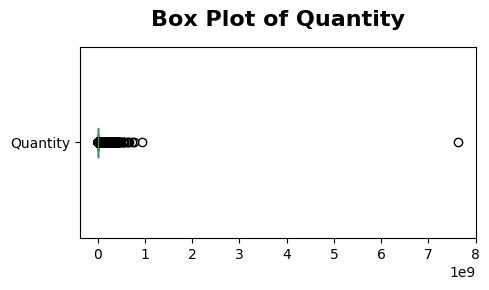

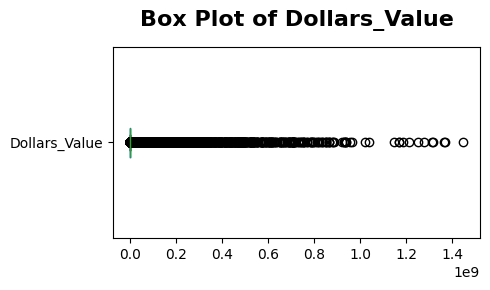

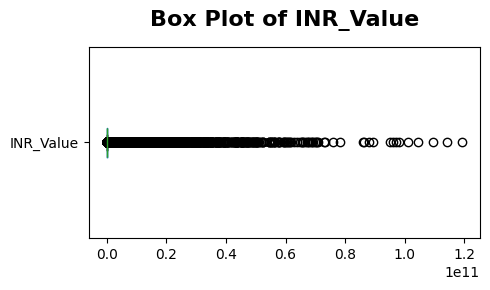

In [97]:
# Box Plot – Distribution and Dispersion of Export Variables

cols = ['Quantity', 'Dollars_Value', 'INR_Value']

for col in cols:

    plt.figure(figsize=(5, 3))

    df.boxplot(column=col, grid = False, vert = False)

    plt.title(f'Box Plot of {col}',fontsize=16,fontweight='bold',pad=15)

    plt.tight_layout()

    plt.show()

### **Interpretation of Box Plots for Variance**

**Quantity:**

* **Extreme Skewness and Outliers:** The box plot is highly right-skewed, with most values concentrated near **0** and outliers reaching **7,620,654,000**.

* **High Variance:** These extreme values contribute to the high variance of     **1.3841 × 10¹³**, indicating substantial dispersion.

**Dollars_Value:**

* **Significant Right Skew:** Most values are concentrated near **0**, while outliers extend up to **$1,449,331,220**.

* **High Variance:** The variance of **2.8155 × 10¹³** indicates significant variation in export values.

**INR_Value:**

* **Extreme Outliers:** The distribution is strongly right-skewed, with values ranging from **₹1** to **₹119,263,437,035**.

* **Very High Variance:** The variance of **1.6600 × 10¹⁷** indicates massive dispersion, largely influenced by extreme high-value exports.

### **Measure of Dispersion : Standard Deviation**

* Small SD → data values are close to the mean → low variation / more consistent

* Large SD → data values are far from the mean → high variation / less consistent

In [98]:
cols = ['Quantity', 'Dollars_Value', 'INR_Value']

In [99]:
# Standard deviation of numeric columns

std_table = df[cols].std().to_frame('STANDARD DEVIATION')

print("MEASURE OF DISPERSION : STANDARD DEVIATION \n\n")

print(std_table)

MEASURE OF DISPERSION : STANDARD DEVIATION 


               STANDARD DEVIATION
Quantity             3.720349e+06
Dollars_Value        5.306167e+06
INR_Value            4.074252e+08


In [100]:
# Calculate mean for each column

means = df[cols].mean()

# Deviation from mean

deviation = df[cols] - means
deviation

,Quantity,Dollars_Value,INR_Value
0,1.808555e+04,-330515.148496,-2.549537e+07
1,-6.391045e+04,827880.851504,4.822137e+07
2,1.117586e+06,262699.851504,1.225498e+07
3,1.717926e+06,401074.851504,2.106077e+07
4,-6.441445e+04,-204008.148496,-1.744483e+07
...,...,...,...
6912487,-6.441445e+04,-356588.148496,-2.712753e+07
6912488,-6.441445e+04,-343507.148496,-2.603813e+07
6912489,-6.441445e+04,-251789.148496,-1.839993e+07
6912490,-6.441445e+04,-321547.148496,-2.420930e+07


**Standard Deviation - Chart**

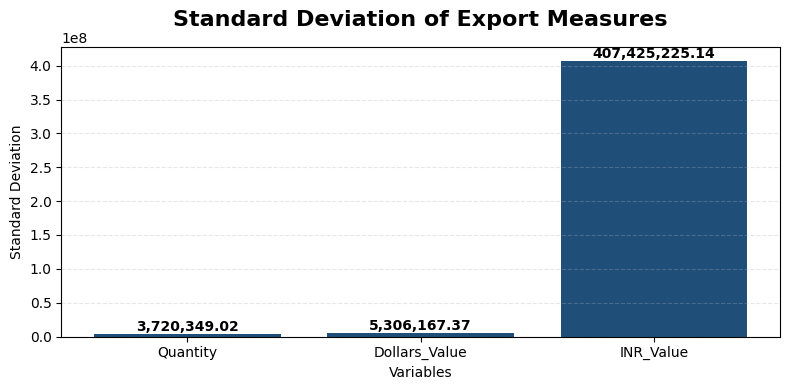

In [101]:
# Calculate standard deviation
plt.figure(figsize=(8, 4))

bar_color = '#1F4E79'

bars = plt.bar(cols, df[cols].std(),color = bar_color)

plt.title('Standard Deviation of Export Measures',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Variables')
plt.ylabel('Standard Deviation')

# Add values on top of bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:,.2f}',          #displays the exact SD value with commas and 2 decimals
        ha='center',              #keeps the value centered above the bar
        va='bottom',               #positions the value neatly above the bar
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Standard Deviation**

**Quantity:** The standard deviation is approximately **3,720,349**, indicating a **very high variation in export quantities**. This means quantities vary significantly from the average quantity, with some records having extremely large export volumes.

**Dollars_Value:** The standard deviation is approximately $**126 million** (based on the dataset statistics), showing **substantial variation in export values**. This indicates that export transactions differ widely in their dollar value.

**INR_Value:** The standard deviation is approximately **₹407.4 million**, indicating **very high dispersion in export values in INR**. A small number of very large-value export records contribute significantly to this variation.

# **VISUALIZATIONS**

**Objective-wise requirement**

**Univariate**

Overall export performance across years → year

Top-performing commodities → commodity

State-wise performance → state_name

**Bivariate**

Yearly export trends → year

Contribution & concentration of commodities/states → commodity, state_name, dollars_value

**Multivariate**

Commodity–state relationship → commodity, state_name, dollars_value

Commodity-wise changes across years → year, commodity, dollars_value



# **Univariate Analysis**

## **Objective 1:**

Analyze the **distribution of export** records across the available **years.**

##**Year-wise Distribution**

In [102]:
# Year-wise record count

year_count = (
    df['Year']
    .value_counts()
    .sort_index()
    .reset_index()
)

year_count.columns = ['Year', 'Count']

year_count

,Year,Count
0,2018,1001226
1,2019,1040115
2,2020,962928
3,2021,1058486
4,2022,1064200
5,2023,1117160
6,2024,668377


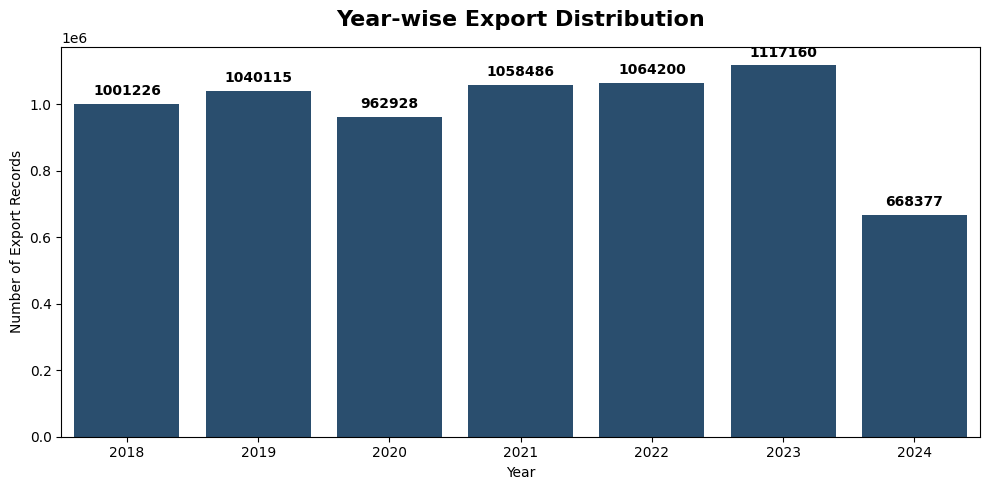

In [103]:
#Year-wise Distribution

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=year_count,
    x='Year',
    y='Count',
    color= '#1F4E79'      #'#4C78A8'
)  # year wise - overall records

plt.title('Year-wise Export Distribution',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Year')
plt.ylabel('Number of Export Records')

# Display count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4,fontsize=10,fontweight = 'bold')

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The **year-wise distribution chart** shows the distribution of export records across the available years. It indicates the number of export records present for each year in the dataset. This helps assess whether the data coverage is relatively consistent or varies across the study period.

**2. Variables Used**

**Year** – Time variable represented on the X-axis.
**Number of Export Records** – Count of records for each year, represented on the Y-axis.

**3. Analysis Objective**

To understand the **year-wise distribution of export records** and verify the availability and representation of data across the study period before analyzing export value and quantity.

**4. Key Finding**

The number of export records varies across the years. **2023 has the highest number of records (1,117,160), while 2024 has the lowest (668,377)**. The relatively lower number of records in 2024 should be considered when comparing yearly results, particularly if the 2024 data represents only part of the year.

## **Objective 2:**

**Identify the top-performing principal commodities** based on their contribution to total export value.

## **Principal Commodities - Wise Distribution**

In [104]:
#Check all records by commodity to find Top Commodities

commodity_count = (
    df['Commodity']
    .value_counts()
    .head(10)
    .reset_index()
)

commodity_count.columns = ['Commodity', 'Count']

commodity_count

,Commodity,Count
0,Products Of Iron And Steel,201592
1,Indl. Machnry For Dairy Etc,186276
2,Electric Machinery And Equipme,169268
3,Other Commodities,161714
4,Other Misc. Engineering Items,153684
5,"Drug Formulations, Biologicals",153617
6,Othr Rubber Prodct Excpt Footw,139528
7,Residul Chemicl And Alled Prod,138518
8,Medical And Scientific Instrum,134077
9,Moulded And Extruded Goods,133686


/tmp/ipykernel_1092/1980447184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


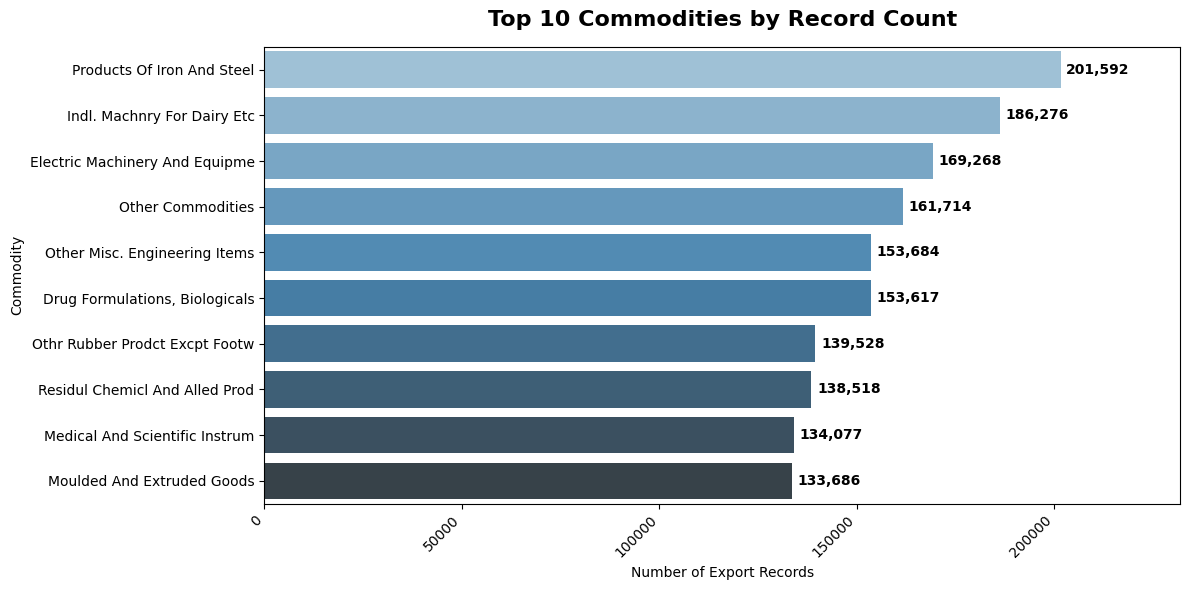

In [105]:
# Distribution of Top 10 Principal Commodities by Record Count

plt.figure(figsize=(12, 6))

ax = sns.barplot(
      data=commodity_count,
      x='Count',
      y='Commodity',

      #color= '#1F4E79'
      palette = 'Blues_d'
  )

plt.title('Top 10 Commodities by Record Count',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Number of Export Records')
plt.ylabel('Commodity')
plt.xticks(rotation=45, ha='right')

  # Display values on each bar
for container in ax.containers:
      ax.bar_label(
          container,
          fmt='{:,.0f}',
          padding=4,
          fontsize=10,
          fontweight = 'bold',
          rotation=0
      )

# Add extra space on the right for value labels
max_value = commodity_count['Count'].max()
ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The countplot shows the **distribution of export records across the principal commodities**. It indicates how frequently each commodity appears in the dataset and highlights the commodities with the highest number of export records.

**2. Variables Used**

* **Commodity** – Categorical variable represented on the X-axis.
* **Number of Export Records** – Frequency/count of records for each commodity represented on the Y-axis.

**3. Analysis Objective**

To understand the **distribution and frequency of principal commodities** in the export dataset and identify the commodities with the highest representation in terms of number of export records.

**4. Key Finding**

**Products Of Iron And Steel** has the highest number of export records with **201,592 records**, followed by **Indl. Machnry For Dairy Etc with 186,276 records and Electric Machinery And Equipme with 169,268 records**. This indicates that these commodities have the highest representation in the dataset based on record frequency.

##**Commodity-Wise Export INR_Value**

In [106]:
# Bivariate Analysis for commoditity-Export INR_value
# Top 10 Principal Commodities by Total Export Value

top_commodities = (
    df.groupby('Commodity', as_index=False)['INR_Value']
      .sum()
      .sort_values('INR_Value', ascending=False)
      .head(10)
)

display(
    top_commodities.style.format({
        'INR_Value': '₹{:,.0f}'
    })
)

,Commodity,INR_Value
117,Petroleum Products,"₹30,958,928,142,188"
116,"Pearl, Precs, Semiprecs Stones","₹11,176,226,107,027"
36,"Drug Formulations, Biologicals","₹9,215,734,966,930"
68,Iron And Steel,"₹6,434,603,245,015"
56,Gold And Oth Precs Metl Jwlery,"₹5,756,153,058,010"
39,Electric Machinery And Equipme,"₹5,024,956,590,408"
158,Telecom Instruments,"₹4,489,669,698,490"
97,Organic Chemicals,"₹4,385,511,952,610"
137,Rmg Cotton Incl Accessories,"₹4,236,693,092,341"
127,Products Of Iron And Steel,"₹4,123,318,098,540"


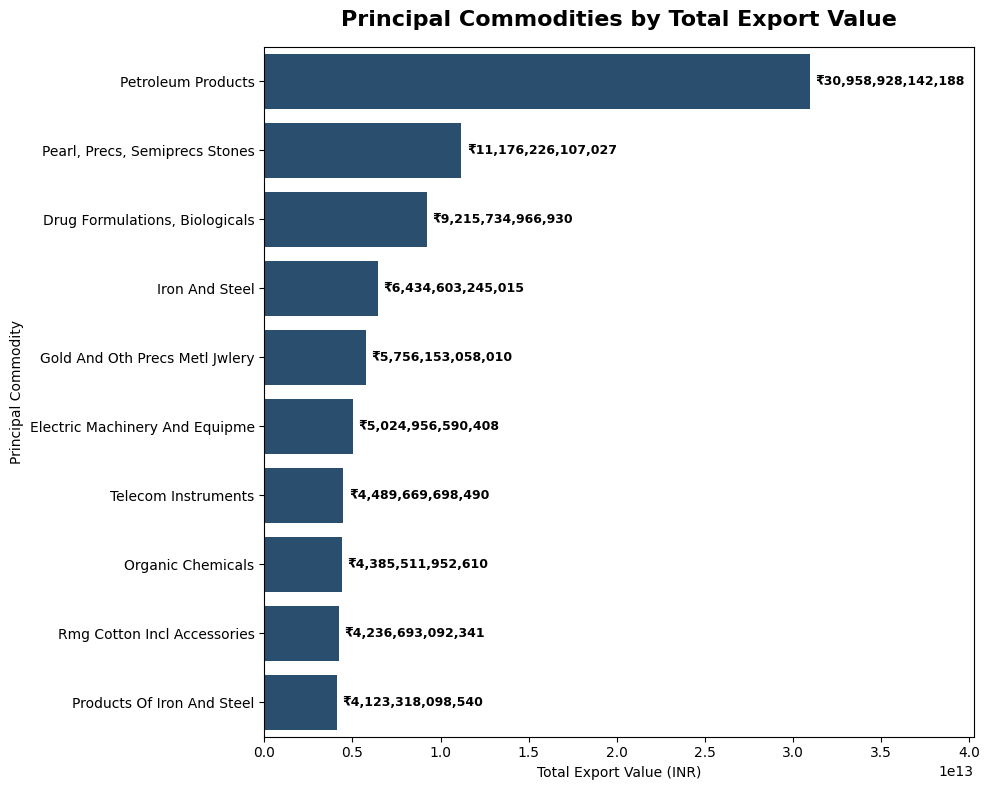

In [107]:
# All Principal Commodities Sorted by Total Export Value

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=top_commodities,
    x='INR_Value',
    y='Commodity',
    color = '#1F4E79'
)

plt.title('Principal Commodities by Total Export Value',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Total Export Value (INR)')
plt.ylabel('Principal Commodity')

# Display INR values at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'₹{value:,.0f}'
            for value in top_commodities['INR_Value']
        ],
        padding=4,
        fontsize=9,
        fontweight='bold'
    )

#Add extra space on the right for value labels

max_value = top_commodities['INR_Value'].max()
ax.set_xlim(0, max_value * 1.30)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The analysis identifies the **top 10 principal commodities based on their total export value in INR.** The ranking shows which commodities contributed the most to India's overall export value during the available study period.

**2. Variables Used**

* **Commodity** – Principal commodity category used to group the export records.

* **INR_Value** – Export value in Indian Rupees, summed for each commodity.

**3. Analysis Objective**

To identify the **top-performing principal commodities** based on their contribution to **India's total export INR value** and determine the major commodity categories driving export earnings.

**4. Key Finding**

* **Petroleum Products ranked 1st** , with a total export value of approximately ₹**30.96 trillion**, making it the highest-value commodity.
* **Pearl, Precs, Semiprecs Stones ranked 2nd**, contributing approximately ₹**11.18 trillion**.
* **Drug Formulations, Biologicals ranked 3rd**, with approximately ₹**9.22 trillion**.
* **Iron And Steel and Gold And Oth Precs Metl Jwlery** were also major contributors, with approximately ₹**6.43 trillion and** ₹**5.76 trillion**, respectively.
* The top 10 commodities demonstrate that India's export value is **concentrated among a relatively small number of major commodity categories**, with Petroleum Products making the largest contribution.

## **Objective 3:**

**Analyze state-wise export performance** and identify the major exporting states.

# **State-Wise Export Performance**

In [108]:
# State-wise record count

state_count = (
    df['State_Name']
    .value_counts()
    .head(10)
    .reset_index()
)

state_count.columns = ['State_Name', 'Count']

state_count

,State_Name,Count
0,Maharashtra,1406584
1,Gujarat,1103124
2,Tamil Nadu,1090166
3,Delhi,694342
4,Karnataka,412865
5,Uttar Pradesh,388880
6,Haryana,317580
7,West Bengal,296353
8,Punjab,272961
9,Kerala,228291


/tmp/ipykernel_1092/4042357129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


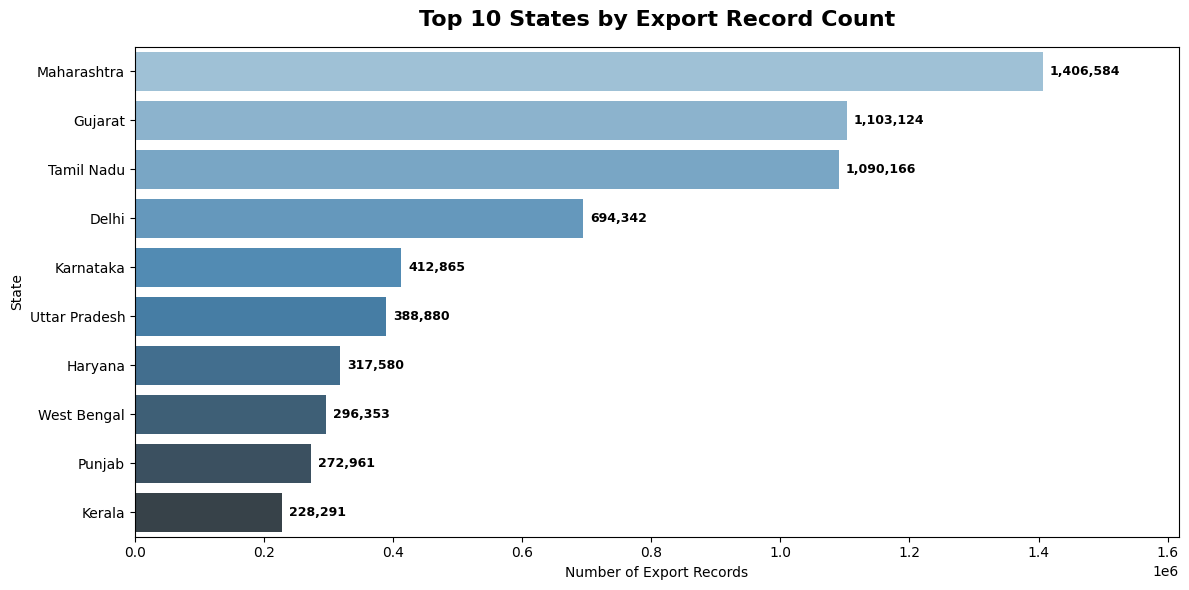

In [109]:
#Top 10 States by Export Record Count
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=state_count,
    x='Count',
    y='State_Name',
    #color = '#1F4E79'
    palette = 'Blues_d'
)

plt.title('Top 10 States by Export Record Count',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Number of Export Records')
plt.ylabel('State')

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize = 9, fontweight = 'bold')

#Add more space on the right for long INR value labels

max_value = state_count['Count'].max()
ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The countplot shows the **distribution of export records across different states**. It indicates the number of export records associated with each state and highlights the states with the highest representation in the dataset.

**2. Variables Used**

* **State_Name** – Categorical variable representing the exporting state.

* **Number of Export Records** – Frequency/count of records for each state.

**3. Analysis Objective**

To understand the **state-wise distribution of export records** and identify the states with the highest representation in the export dataset.

**4. Key Finding**

**Maharashtra** has the highest number of export records with **1,406,584 records**, followed by **Gujarat with 1,103,124 records** and **Tamil Nadu with 1,090,166 records**. **Delhi ranks fourth with 694,342 records**. This indicates that these states have the highest representation in the dataset based on the number of export records.

# **Top 10 States by Export - Dollar_Value (USD)**

In [124]:
#Find the Top 10 States using Dollar_Value(USD)
# Calculate total export value by state
state_export_value = (
    df.groupby('State_Name', as_index=False)['Dollars_Value']
      .sum()
      .sort_values('Dollars_Value', ascending=False)
)

# Select Top 10 states
top_10_states = state_export_value.head(10)

# Display with USD formatting
display(
    top_10_states.style.format({
        'Dollars_Value': '${:,.2f}'
    })
)

,State_Name,Dollars_Value
15,Maharashtra,"$678,626,514,795.00"
7,Gujarat,"$666,913,780,426.00"
23,Tamil Nadu,"$280,251,142,110.00"
0,Andhra Pradesh,"$118,704,635,586.00"
5,Delhi,"$110,313,897,850.00"
12,Karnataka,"$108,826,793,296.00"
29,West Bengal,"$95,641,577,911.00"
26,Uttar Pradesh,"$89,677,716,357.00"
24,Telangana,"$56,510,585,130.00"
13,Kerala,"$50,379,518,069.00"


/tmp/ipykernel_1092/1784409075.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




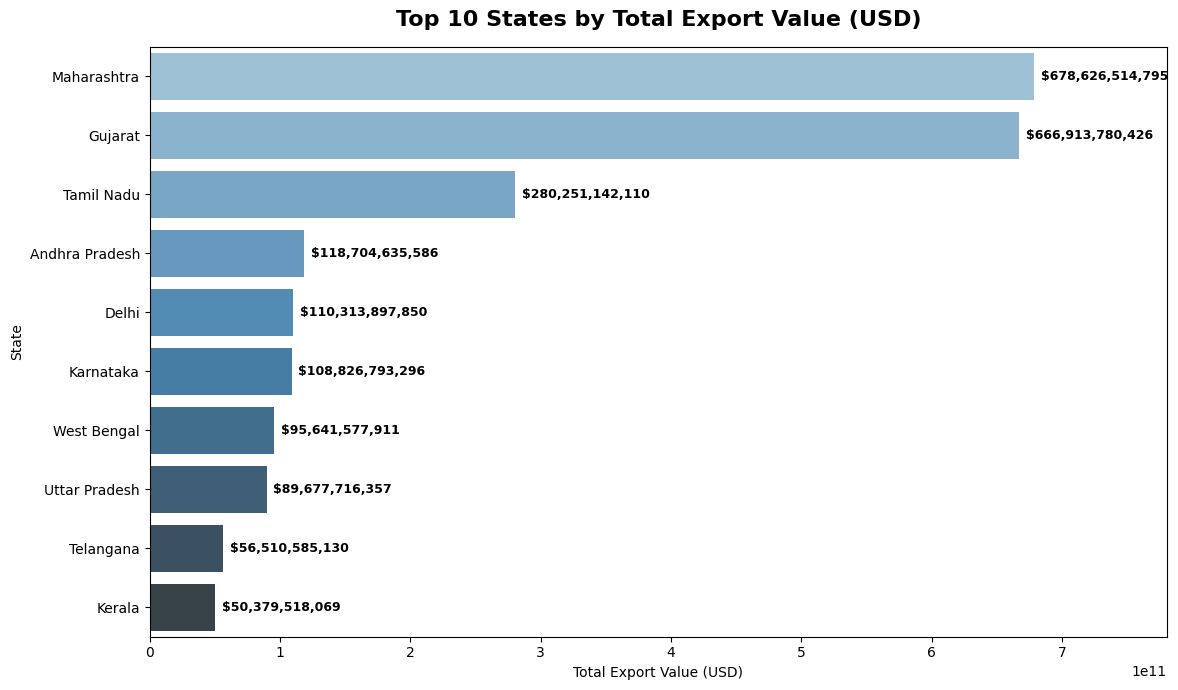

In [131]:
# Create horizontal bar chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_states,
    x='Dollars_Value',
    y='State_Name',
    palette='Blues_d'
)

plt.title(
    'Top 10 States by Total Export Value (USD)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Total Export Value (USD)')
plt.ylabel('State')

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='${:,.0f}',
        padding=5,
        fontsize=9,
        fontweight='bold'
    )

# Add more space on the right for long USD value labels
max_value = top_10_states['Dollars_Value'].max()
ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The chart compares the **Top 10 Indian states based on total export value in USD during the period 2018–2024**. Maharashtra and Gujarat recorded substantially higher export values than the other states, while Tamil Nadu ranked third. The remaining states show comparatively lower total export values.

**2. Variables Used**

**State_Name** – Indian state associated with the export activity, represented on the Y-axis.

**Dollars_Value** – Total export value in US Dollars (USD), represented on the X-axis.

**3. Analysis Objective**

To evaluate state-wise export performance by calculating the **total export value in USD** for each state and identifying the **Top 10 major exporting states during 2018–2024**.

**4. Key Finding**

Maharashtra recorded the highest total export value of $678.63 billion, closely followed by Gujarat with $666.91 billion. Tamil Nadu ranked third with $280.25 billion. Among the remaining states, Andhra Pradesh ($118.70 billion), Delhi ($110.31 billion), and Karnataka ($108.83 billion) were the next major contributors.

# **Bivariate Analysis**

## **Objective 4:**

**Examine yearly export trends** to identify growth, decline, and changes in export performance over time.

# **Year - Wise Export Value of India**

In [110]:
# Groupby Year - Dollors_value

yearly_export_value = df.groupby('Year')['Dollars_Value'].sum().reset_index()
display(
    yearly_export_value.style.format({
    'Dollars_Value': '${:,.2f}'
    })
    )

,Year,Dollars_Value
0,2018,"$324,843,545,617.00"
1,2019,"$324,267,556,306.00"
2,2020,"$276,467,086,082.00"
3,2021,"$395,471,826,573.00"
4,2022,"$453,259,802,672.00"
5,2023,"$435,741,536,435.00"
6,2024,"$264,386,784,065.00"


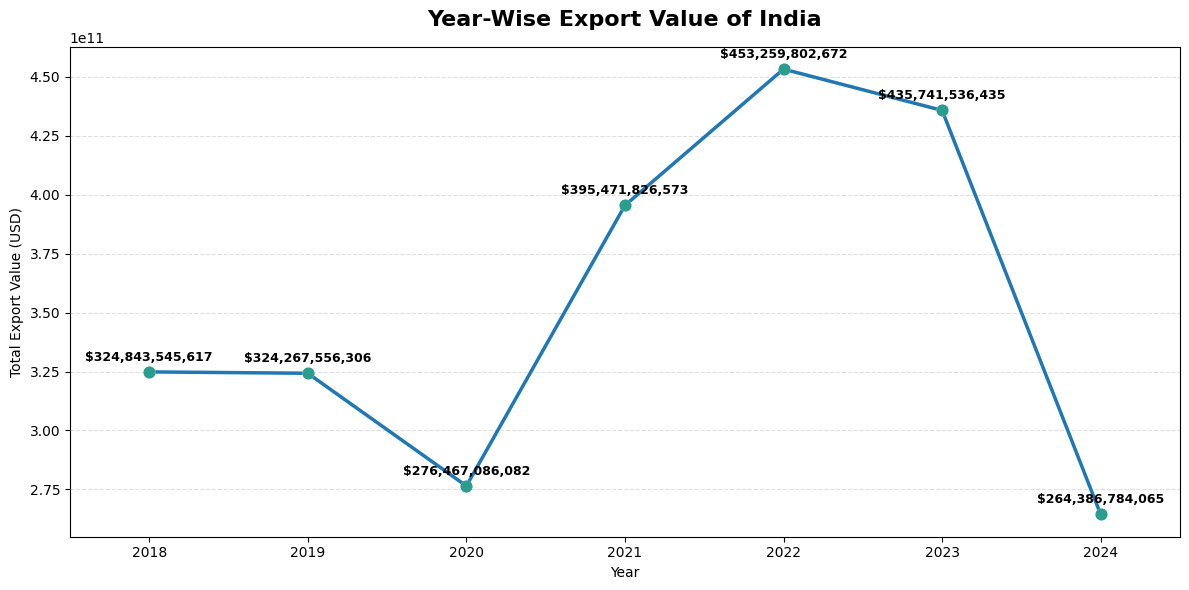

In [111]:
# Found the Year-wise Total Export -Dollar_Value(USD)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_export_value,
    x='Year',
    y='Dollars_Value',
    marker='o',
    markersize=8,
    linewidth=2.5
)

plt.title('Year-Wise Export Value of India',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Year')
plt.ylabel('Total Export Value (USD)')
plt.xticks(yearly_export_value['Year'])

#Add accent color to markers

plt.scatter(
yearly_export_value['Year'],
yearly_export_value['Dollars_Value'],
color='#2A9D8F',
s=60,
zorder=3
)

# Display values on each marker
for x, y in zip(yearly_export_value['Year'], yearly_export_value['Dollars_Value']):
    #plt.text(x, y, f'${y:,.0f}', ha='center', va='bottom')

  plt.annotate(
  f'${y:,.0f}',
  (x, y),
  textcoords='offset points',
  xytext=(0, 8),
  ha='center',
  fontsize=9,
  fontweight='bold'
)

#Add space on the left and right of the first and last year

years = yearly_export_value['Year']
plt.xlim(years.min() - 0.5, years.max() + 0.5)

plt.xticks(years)

#Add light horizontal Grid lines

plt.grid(axis='y', linestyle='--',
alpha=0.4
)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The line chart shows the year-wise trend in India's total export value from 2018 to 2024. Export value increased and decreased across the years, showing periods of growth as well as decline. The highest export value was recorded in 2022, while the lowest was recorded in 2024.

**2. Variables Used**

* Year – Represents the year of export.

* Dollars_Value – Represents the total export value in USD for each year.

**3. Analysis Objective**

To analyze India's overall export performance across the available years based on total export value and identify major increases and decreases in export performance.

**4. Key Finding**

* Export value was relatively stable in **2018–2019**.

* Export value declined in 2020 to approximately $**276.47 billion**.

* A strong recovery occurred during **2021–2022**, reaching the highest value of approximately $**453.26 billion in 2022**.

* Export value declined to approximately $**435.74  billion in 2023 and further to 264.39 billion in 2024**.

* Overall, **2022 was the strongest export year**, while 2024 recorded the lowest export value among the available years.

In [112]:
# Check the total months of year(2018-2024)
# India's exports declined sharply in 2024.Therefore, the apparent decline in 2024 is at least partly explained by incomplete year coverage

months_per_year = (
    df.groupby('Year')['Month_Name']
      .nunique()
      .reset_index(name='Number_of_Months')
)

months_per_year

,Year,Number_of_Months
0,2018,12
1,2019,12
2,2020,12
3,2021,12
4,2022,12
5,2023,12
6,2024,7


**Key Finding**

The recorded export value for 2024 was lower than previous full-year values; however, 2024 contains only 7 months of data, so the lower value should not be interpreted as an annual decline in India's export performance.

## **Objective 5:**

**Analyze the relationship between commodities and states** to identify which commodities contribute significantly to exports from different states

# **State - Wise Export Value Across Top 20 Commodities**

In [113]:
# Identify Top 20 Commodities based on total export value

top_20_commodities = (
    df.groupby('Commodity')['INR_Value']
      .sum()
      .sort_values(ascending=False)
      .head(20)
      .index
)
top_20_commodities

Index(['Petroleum Products', 'Pearl, Precs, Semiprecs Stones',
       'Drug Formulations, Biologicals', 'Iron And Steel',
       'Gold And Oth Precs Metl Jwlery', 'Electric Machinery And Equipme',
       'Telecom Instruments', 'Organic Chemicals',
       'Rmg Cotton Incl Accessories', 'Products Of Iron And Steel',
       'Motor Vehicle/Cars', 'Aluminium, Products Of Aluminm',
       'Marine Products', 'Indl. Machnry For Dairy Etc',
       'Residul Chemicl And Alled Prod', 'Cotton Fabrics, Madeups Etc.',
       'Auto Components/Parts', 'Manmade Yarn,Fabrics,Madeups',
       'Rice -Basmoti', 'Other Commodities'],
      dtype='object', name='Commodity')

In [114]:
# Filter the dataset to Top 20 commodities
df_top20 = df[df['Commodity'].isin(top_20_commodities)]

# Create State × Commodity pivot table
state_commodity = pd.pivot_table(
    df_top20,
    index='State_Name',
    columns='Commodity',
    values='INR_Value',
    aggfunc='sum',
    fill_value=0
)

# Arrange commodities according to overall Top 20 ranking
state_commodity = state_commodity[top_20_commodities]

# Display the pivot table
display(state_commodity)

Commodity,Petroleum Products,"Pearl, Precs, Semiprecs Stones","Drug Formulations, Biologicals",Iron And Steel,Gold And Oth Precs Metl Jwlery,Electric Machinery And Equipme,Telecom Instruments,Organic Chemicals,Rmg Cotton Incl Accessories,Products Of Iron And Steel,Motor Vehicle/Cars,"Aluminium, Products Of Aluminm",Marine Products,Indl. Machnry For Dairy Etc,Residul Chemicl And Alled Prod,"Cotton Fabrics, Madeups Etc.",Auto Components/Parts,"Manmade Yarn,Fabrics,Madeups",Rice -Basmoti,Other Commodities
State_Name,,,,,,,,,,,,,,,,,,,,
Andhra Pradesh,266844150314,11029907912,934969452634,1373939610110,91744698,96740878840,6884637219,89668474907,62865707925,35559215638,58341416,668365340774,1180221309388,22187477280,219253439636,4665260375,20734816487,5278646394,227292627,55341970745
Assam,18249404773,17082,12867620,2827511247,209960,854438266,171119673,15949485,113608961,1665106897,25014019,199389409,90377170,792863965,200687150,83303590,258399242,366940228,379067875,1674969860
Bihar,701557824064,2609950,81138791005,353657831667,2728642,54766028693,7864594376,6622818905,3967610440,38347823391,49698317525,22068792666,1612328209,65677030674,14327292216,13165174103,31790525866,17999927741,3266253228,26934244563
Chandigarh,0,0,0,0,0,0,1533950,0,0,0,0,0,0,36756,0,0,0,0,0,855623
Chhattisgarh,9205140,0,0,100693925,0,0,0,0,0,165683872,0,0,0,105066392,0,0,0,0,354750,78515580
Delhi,461362051534,4460673865,487487340935,16328248374,450254329545,1481146131350,434618700081,39828995185,540190531226,136616822055,3211914997,20127287739,50150828,160815872725,68692200173,78840392131,221708301830,38961495946,10391013270,68323264624
Goa,1557311002,0,12366615968,441675522126,80585827,1706785955,4338314527,128826498,3023949,4327965220,0,2494306,14937827076,5042276231,229850197,113724,7698240,126214025,0,77704269
Gujarat,24458455383129,627362220131,1142550650337,520407387769,900942299905,297365086245,62193677213,1917886074444,58327395604,916821067710,707885565201,79367569423,342523400210,386538988723,661928292177,630823791593,110550448984,780773016711,1481229699350,389418201938
Haryana,5438656269,161429640,38390075649,161305287139,25767423,141314847536,906612417,22710576448,143770993138,114762979871,1069647923,35054622944,4593624,90977028314,14747745984,106789844333,264176299537,27638965555,511920987366,51869446077


In [115]:
#Creates the heatmap using - plotpy library

fig = px.imshow(
    state_commodity,
    color_continuous_scale='Blues',
    aspect='auto',
    labels={
        'x': 'Commodity',
        'y': 'State',
        'color': 'Export Value (₹)'
    },

    title='State-wise Export Value Across Top 20 Commodities',
)

# Show State, Commodity and ₹ Export Value details when hovering over a cell
fig.update_traces(
    xgap = 1,
    ygap = 1,
    hovertemplate='State: %{y}<br>' +      #Shows State, Commodity and ₹ Export Value when hovering
                  'Commodity: %{x}<br>'+
                  'Export Value: ₹%{z:,.0f}<extra></extra>'   #removes unnecessary trace information from hover.
)

fig.update_layout(
    width=1400,
    height=800,

    # Professional title formatting
    title={ 'text' : '<b>State-wise Export Value Across Top 20 Commodities</b>',
            'font': { 'size': 22 ,'color' : 'black'},
            'x': 0.5,
            'xanchor': 'center',
            'pad': {'b': 15} },

    xaxis_tickangle=-45, #Rotates commodity names for readability


    # Improve margins and spacing
    margin=dict(l=150, r=80, t=100, b=180)
)
fig.show()

**1. Chart Interpretation**

The heatmap illustrates the relationship between **states and the Top 20 principal commodities** based on total export value. Each cell represents the total export value of a particular commodity from a particular state. Darker shades indicate relatively higher export values, while lighter shades indicate lower values.

**2. Variables Used**

* **State_Name** – Categorical variable representing the exporting states on the Y-axis.
* **Commodity** – Categorical variable representing the Top 20 principal commodities on the X-axis.
* **INR_Value** – Numerical variable aggregated as the total export value for each state–commodity combination.

**3. Analysis Objective**

To analyze the relationship between states and commodities and identify which principal commodities contribute significantly to exports from different states.

**4. Key Finding**

The heatmap highlights differences in commodity-wise export concentration across states. Darker cells identify state–commodity combinations with relatively higher export values, helping identify which commodities are particularly significant for individual states.

# **Multivariate Analysis**

## **Objective 6:**

**Identify major changes in commodity-wise export performance** across different years.

# **Commodity - Wise Export Performance Across Years**

In [116]:
# Commodity-wise Export Performance Across Years

commodity_year = (
    df.groupby(['Year', 'Commodity'], as_index=False)['INR_Value']
      .sum()
)
commodity_year

# Display INR values with ₹ symbol
display(
    commodity_year.style.format({
        'INR_Value': '₹{:,.2f}'
    })
)

,Year,Commodity,INR_Value
0,2018,"Ac, Refrigeration Machnry Etc","₹133,303,433,207.00"
1,2018,Accumulators And Batteries,"₹25,039,926,900.00"
2,2018,Agro Chemicals,"₹203,790,514,153.00"
3,2018,"Aircraft, Spacecraft And Parts","₹138,808,466,080.00"
4,2018,Alcoholic Beverages,"₹21,258,663,427.00"
5,2018,"Aluminium, Products Of Aluminm","₹391,312,039,491.00"
6,2018,Animal Casings,"₹4,720,742,955.00"
7,2018,"Atm, Injctng Mlding Mchnry Etc","₹107,514,727,741.00"
8,2018,Auto Components/Parts,"₹390,250,312,780.00"
9,2018,Auto Tyres And Tubes,"₹129,119,028,890.00"


In [117]:
# Select top 5 commodities based on overall export value
top_5_commodities = (
    df.groupby('Commodity')['INR_Value']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)
top_5_commodities

Index(['Petroleum Products', 'Pearl, Precs, Semiprecs Stones',
       'Drug Formulations, Biologicals', 'Iron And Steel',
       'Gold And Oth Precs Metl Jwlery'],
      dtype='object', name='Commodity')

In [118]:
# Filter only top 5 commodities
commodity_year_top5 = commodity_year[
    commodity_year['Commodity'].isin(top_5_commodities)
]
commodity_year_top5

# Display INR values with ₹ symbol
display(
    commodity_year_top5.style.format({
        'INR_Value': '₹{:,.2f}'
    })
)

,Year,Commodity,INR_Value
36,2018,"Drug Formulations, Biologicals","₹949,823,919,945.00"
56,2018,Gold And Oth Precs Metl Jwlery,"₹856,829,908,896.00"
68,2018,Iron And Steel,"₹683,791,601,192.00"
116,2018,"Pearl, Precs, Semiprecs Stones","₹1,807,605,428,230.00"
117,2018,Petroleum Products,"₹3,243,590,830,324.00"
204,2019,"Drug Formulations, Biologicals","₹1,118,492,925,072.00"
224,2019,Gold And Oth Precs Metl Jwlery,"₹963,113,381,195.00"
236,2019,Iron And Steel,"₹688,115,643,723.00"
284,2019,"Pearl, Precs, Semiprecs Stones","₹1,606,074,326,463.00"
285,2019,Petroleum Products,"₹2,960,898,728,421.00"


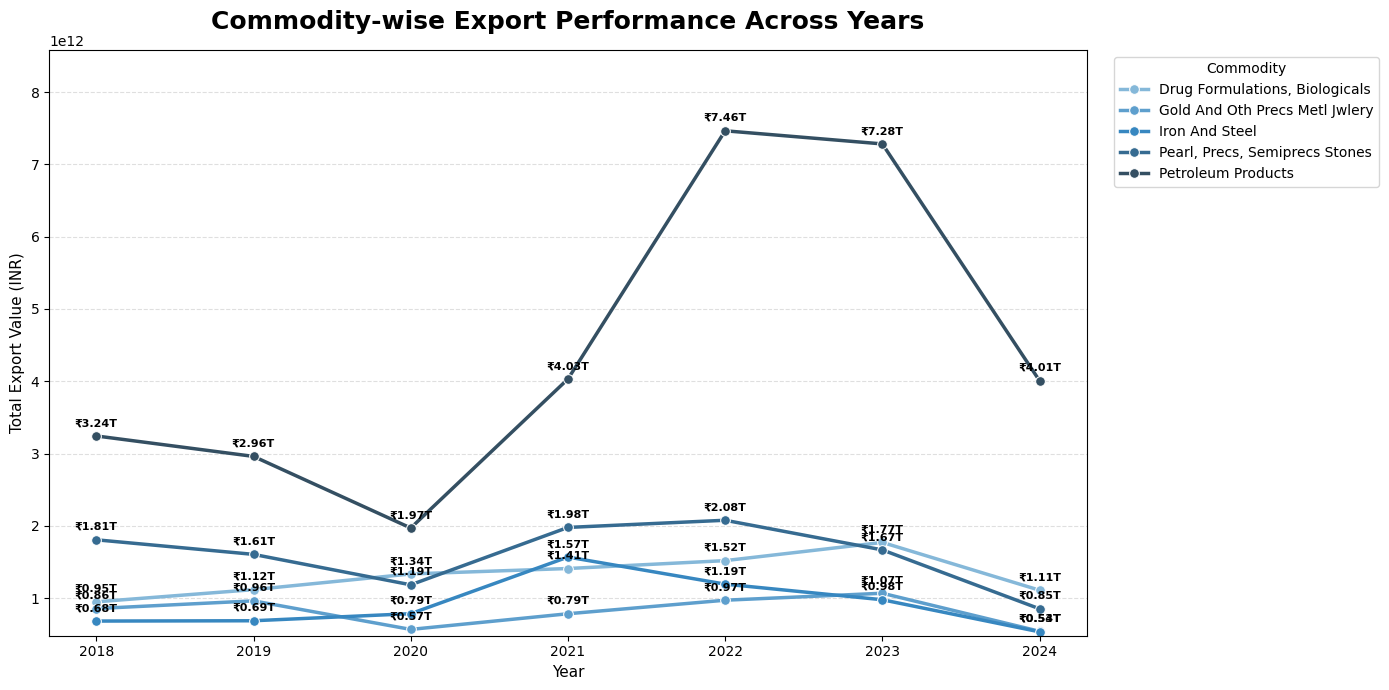

In [119]:
#Commodity-wise Export Performance Across Years-using lineplot
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=commodity_year_top5,
    x='Year',
    y='INR_Value',
    hue='Commodity',
    marker='o',
    palette='Blues_d',
    linewidth=2.5,
    markersize=7
)

plt.title('Commodity-wise Export Performance Across Years',
          fontsize=18,
          fontweight='bold',
          pad=15,
          color='black')
plt.xlabel('Year',fontsize=11)

plt.ylabel('Total Export Value (INR)',fontsize=11)

plt.xticks(sorted(commodity_year_top5['Year'].unique()))

# Display INR values on each marker
for _, row in commodity_year_top5.iterrows():
    value_trillion = row['INR_Value'] / 1_000_000_000_000

    plt.annotate(
        f'₹{value_trillion:.2f}T',
        (row['Year'], row['INR_Value']),
        textcoords='offset points',
        xytext=(0, 7),
        ha='center',
        fontsize=8,
        fontweight='bold'
    )
# Add extra space above the highest value
max_value = commodity_year_top5['INR_Value'].max()
min_value = commodity_year_top5['INR_Value'].min()

plt.ylim(
    min_value * 0.90,
    max_value * 1.15
)

# Add light horizontal grid lines
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.legend(
    title='Commodity',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

which commodities performed strongly in each year

which commodities increased or decreased

which commodities experienced major changes over time.

**1. Chart Interpretation**

The line plot shows the **year-wise export performance of the top 5 commodities** based on their total INR export value. Each line represents one commodity, allowing the changes in export value across 2018–2024 to be compared.

The chart highlights periods of **growth, decline, and fluctuation** in the export performance of these major commodities.

**2. Features / Columns Used**

* Year – Represents the export year from 2018 to 2024.

* Commodity – Represents the selected top 5 principal commodities.

* INR_Value – Represents the total export value in Indian Rupees for each commodity in each year.

**Top 5 commodities selected:**

* Petroleum Products
* Pearl, Precs, Semiprecs Stones
* Drug Formulations, Biologicals
* Iron And Steel
* Gold And Oth Precs Metl Jwlery

**3. Analysis Objective**

To **identify major changes in the export performance of leading commodities across different years** and determine which commodities experienced significant growth, decline, or fluctuations during 2018–2024.

**4. Key Finding**

* **Petroleum Products** remained the strongest-performing commodity throughout the period. Its export value increased sharply from approximately ₹**3.24 trillion in 2018 to ₹7.46 trillion in 2022**, followed by a decline in **2023 and 2024.**

* **Pearl, Precs, Semiprecs Stones** showed a declining trend from ₹**1.81 trillion in 2018** to ₹**1.19 trillion in 2020**, followed by a **strong recovery in 2021–2022** and another **decline in 2023–2024**.

* **Drug Formulations, Biologicals** showed relatively strong growth from ₹**0.95 trillion in 2018** to ₹**1.77 trillion in 2023**, before declining to approximately ₹**1.11 trillion in 2024**.

* **Iron And Steel** experienced its most significant growth between 2020 and 2021, increasing from approximately ₹**0.79 trillion** to ₹**1.57 trillion**, followed by a decline in subsequent years.

* **Gold And Oth Precs Metl Jwlery** showed considerable fluctuations, reaching approximately ₹**1.07 trillion in 2023** before falling to ₹**0.54 trillion in 2024.**

* Overall, **2022 was a particularly strong year for Petroleum Products and Pearl, Precs, Semiprecs Stones**, while 2024 shows a noticeable decline across all five selected commodities.

# **Objective 7:**

**Measure the contribution and concentration of major commodities and states** in India's overall exports.

# **Measure Export Contribution and Concentration**

**Commodity → contribution to total export value → concentration**

**Chart 1** — Top 10 Commodities by Contribution to Total Export Value

**Purpose:** Measure how much each major commodity contributes to India's overall export value.

In [136]:
#Find the contribution percentage

# Total export value by commodity
commodity_contribution = (
    df.groupby('Commodity', as_index=False)['Dollars_Value']
      .sum()
      .sort_values('Dollars_Value', ascending=False)
)

# Total export value
total_export_value = commodity_contribution['Dollars_Value'].sum()

# Calculate contribution percentage
commodity_contribution['Contribution_%'] = (
    commodity_contribution['Dollars_Value']
    / total_export_value
    * 100
)

commodity_contribution


,Commodity,Dollars_Value,Contribution_%
117,Petroleum Products,401606121997,16.230194
116,"Pearl, Precs, Semiprecs Stones",149108449288,6.025952
36,"Drug Formulations, Biologicals",120959016637,4.888343
68,Iron And Steel,85228791749,3.444369
56,Gold And Oth Precs Metl Jwlery,76306456028,3.083789
...,...,...,...
105,Other Meat,17428135,0.000704
124,Processed Meat,12812771,0.000518
133,Raw Hides And Skins,7247638,0.000293
149,"Silk,Raw",5855786,0.000237


/tmp/ipykernel_1092/1452686014.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




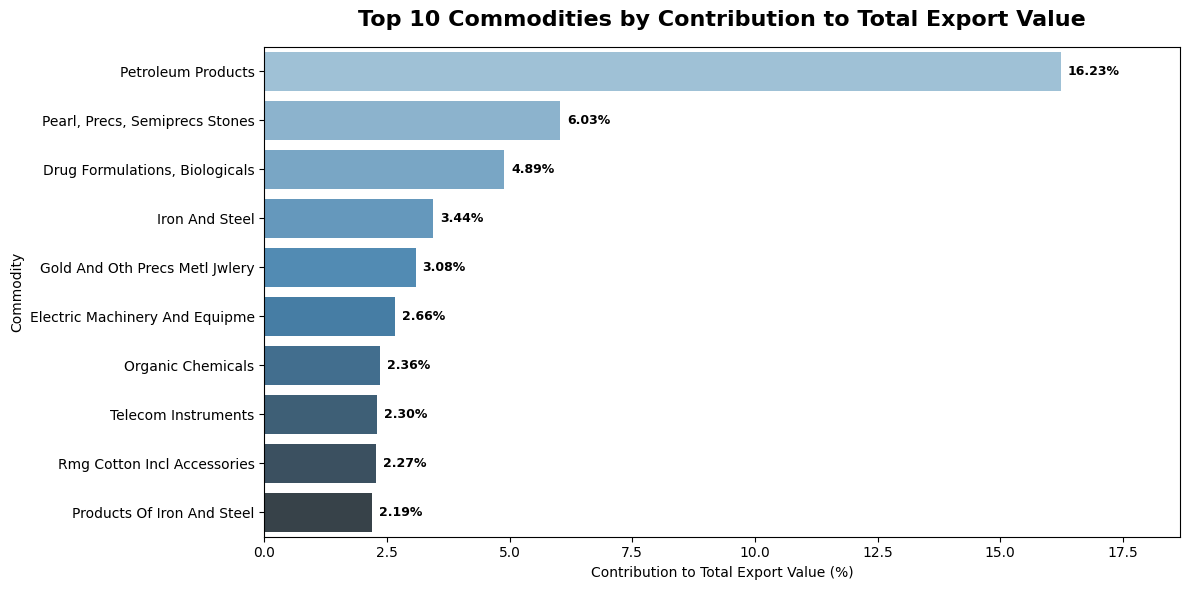

In [139]:
#Top 10 Commodities by Contribution to Total Export Value

# Select Top 10 commodities
top_10_commodity_contribution = commodity_contribution.head(10)


plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10_commodity_contribution,
    x='Contribution_%',
    y='Commodity',
    palette='Blues_d'
)

plt.title(
    'Top 10 Commodities by Contribution to Total Export Value',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Contribution to Total Export Value (%)')
plt.ylabel('Commodity')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=5,
        fontsize=9,
        fontweight='bold'
    )

# Provide space for labels
max_value = top_10_commodity_contribution['Contribution_%'].max()
ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The chart compares the contribution of the **Top 10 principal commodities** to India's total export value. **Petroleum Products** has the highest contribution at **16.23**%, followed by **Pearl, Precs, Semiprecs Stones at 6.03**% and **Drug Formulations, Biologicals at 4.89**%. The remaining commodities contribute smaller shares individually.

**2. Variables Used**

**Commodity** – Principal commodity category represented on the Y-axis.

**Contribution_%** – Percentage contribution of each commodity to India's total export value, represented on the X-axis.

**Dollars_Value** – Total export value in USD used to calculate each commodity's contribution.

**3. Analysis Objective**

To **measure the contribution of major principal commodities** to India's overall export value and identify the commodities that account for the largest share of total exports.

**4. Key Finding**

Petroleum Products is the largest contributor, accounting for **16.23**% of India's total export value, followed by **Pearl, Precs, Semiprecs Stones (6.03%) and Drug Formulations, Biologicals (4.89%)**. The results indicate that export value is concentrated among a limited number of major commodities, with **Petroleum Products having a substantially higher contribution than the other leading commodities.**

**Chart 2** — Cumulative Contribution of Top 20 Commodities

**Purpose:** Measure concentration — whether a large share of India's export value is concentrated among a relatively small number of commodities.

In [146]:
# Select Top 20 commodities
top_20_commodity_contribution = commodity_contribution.head(20).copy()

# Calculate cumulative contribution
top_20_commodity_contribution['Cumulative_%'] = (
    top_20_commodity_contribution['Contribution_%'].cumsum()
)
top_20_commodity_contribution

,Commodity,Dollars_Value,Contribution_%,Cumulative_%
117,Petroleum Products,401606121997,16.230194,16.230194
116,"Pearl, Precs, Semiprecs Stones",149108449288,6.025952,22.256146
36,"Drug Formulations, Biologicals",120959016637,4.888343,27.144489
68,Iron And Steel,85228791749,3.444369,30.588858
56,Gold And Oth Precs Metl Jwlery,76306456028,3.083789,33.672648
39,Electric Machinery And Equipme,65913319711,2.663769,36.336417
97,Organic Chemicals,58293405387,2.355824,38.692241
158,Telecom Instruments,56853714416,2.297641,40.989882
137,Rmg Cotton Incl Accessories,56209771250,2.271618,43.261500
127,Products Of Iron And Steel,54168117350,2.189108,45.450607


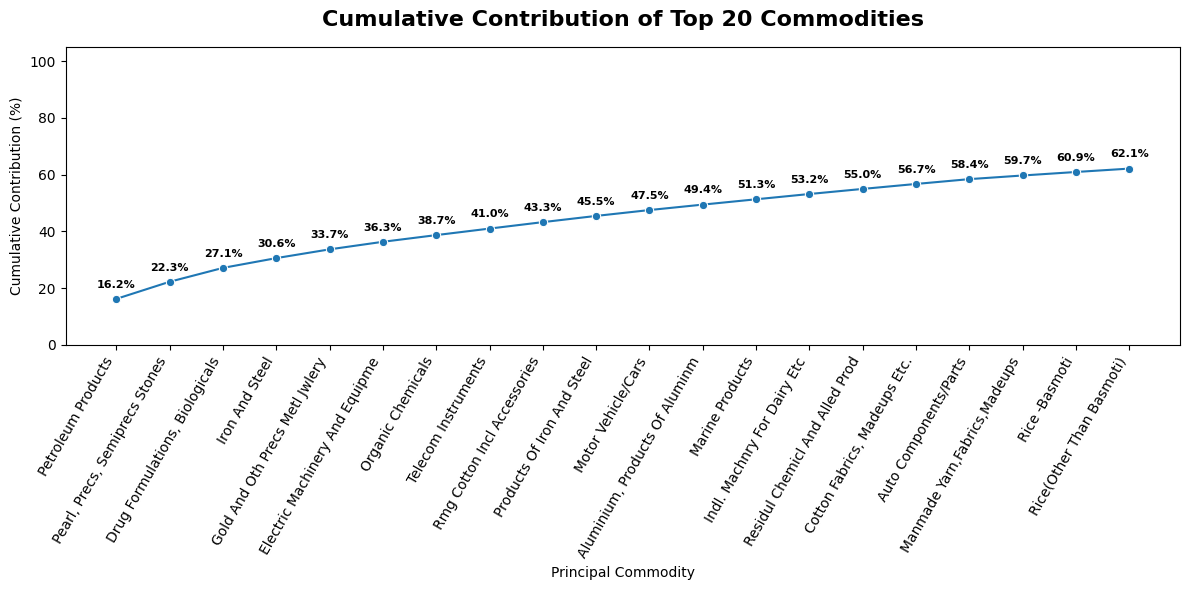

In [143]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=top_20_commodity_contribution,
    x='Commodity',
    y='Cumulative_%',
    marker='o'
)

plt.title(
    'Cumulative Contribution of Top 20 Commodities',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Principal Commodity')
plt.ylabel('Cumulative Contribution (%)')

plt.xticks(
    rotation=60,
    ha='right'
)

# Add cumulative percentage labels
for x, y in enumerate(
    top_20_commodity_contribution['Cumulative_%']
):
    ax.annotate(
        f'{y:.1f}%',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

**1. Chart Interpretation**

The chart shows the cumulative contribution of the **Top 20 principal commodities** to India's total export value. **Petroleum Products** alone contributes **16.23**%, while the first five commodities together account for **33.67**% of total export value. The cumulative contribution increases progressively as additional commodities are included, reaching **62.12**% with the Top 20 commodities.

**2. Variables Used**

**Commodity** – Principal commodity ranked by total export value.

**Contribution_%** – Individual percentage contribution of each commodity to total export value.

**Cumulative_%** – Running total of commodity contributions, showing the combined contribution of the leading commodities.

**Dollars_Value** – Total export value in USD for each commodity, used to calculate contribution.

**3. Analysis Objective**

To **measure the concentration of India's export value among major principal commodities** and determine the extent to which the leading commodities contribute to the country's overall exports.

**4. Key Finding**

The **Top 20 commodities collectively contribute 62.12%** of India's total export value, indicating a **high concentration of export value among major commodities.** The first five commodities account for **33.67%**, while **Petroleum Products alone contributes 16.23%**, making it the largest individual contributor. This indicates that a relatively small group of commodities plays a significant role in India's overall export performance.

In [145]:
#Supporting analysis — Year × Commodity

year_commodity = (
    df.groupby(['Year', 'Commodity'])['Dollars_Value']
      .sum()
      .reset_index()
)

year_commodity_pivot = (
    year_commodity
    .pivot(
        index='Year',
        columns='Commodity',
        values='Dollars_Value'
    )
)

year_commodity_pivot

Commodity,"Ac, Refrigeration Machnry Etc",Accumulators And Batteries,Agro Chemicals,"Aircraft, Spacecraft And Parts",Alcoholic Beverages,"Aluminium, Products Of Aluminm",Animal Casings,"Atm, Injctng Mlding Mchnry Etc",Auto Components/Parts,Auto Tyres And Tubes,...,Telecom Instruments,Tin And Products Made Of Tin,Tobacco Manufactured,Tobacco Unmanufactured,Two And Three Wheelers,Vegetable Oils,Wheat,"Wollen Yarn,Fabrics,Madeupsetc","Wool, Raw",Zinc And Products Made Of Zinc
Year,,,,,,,,,,,,,,,,,,,,,
2018,1942819922,364543529,2970859956,2051600475,311094561,5713451899,68202818,1570191536,5703475008,1888868091,...,2139818761,10243646,395794307,590053416,2142046205,103348883,62871661,210153413,1395205,750216073
2019,1541036569,422423906,3445966717,1477253310,250104428,5250007453,54890365,1785951259,5561542694,1922355140,...,4409175125,10431989,410695232,554717582,2091892306,138269650,69975667,204207232,156607,555883749
2020,1038407997,365891417,3421545117,1223056671,309917454,5353277911,58690098,1563085016,4490349606,1798054378,...,4102161862,9071776,336029140,510721496,1839761656,442777687,292835539,119301436,109253,701357186
2021,1362627593,601940965,4495266827,1120146392,275080054,9132028179,65756010,1870234749,6776931444,2773247182,...,6701448664,17288011,357494359,555266216,2948270832,379968285,1741862191,148011274,93704,859293008
2022,1646207531,803501305,5551134412,1372411738,318034398,10050558982,44491556,2240421392,7273257328,3077181189,...,11094755386,13774505,400498683,810715924,2934955282,364952238,2178104310,196349068,466430,1359305590
2023,1687358549,767477142,4332279733,2117086655,369664797,7373241124,43876413,2540657090,7505816280,2757351930,...,15943627889,14201206,374799572,967609415,2616811918,399565085,48101004,202431804,548900,889408478
2024,1051902078,550330702,2420647001,3494428834,224155606,4529891767,31032329,1578846434,4725407065,1811143684,...,12462726729,11563900,264509679,647785003,1794845557,361077010,21923812,100616896,294929,399859365


**Stage 3 : Completed**

**Overall Finding:**
The analysis shows that India's exports are highly concentrated across major commodities and states. Export performance changed considerably over the years, with a strong recovery after 2020 and the highest overall export value in 2022. The commodity–state analysis also highlights regional specialization and differences in commodity performance over time.

In [120]:
#Save final cleaned dataframe as CSV
df.to_csv(
    'india_exports_cleaned.csv',
    index=False
)

In [121]:
df.shape

(6912492, 15)

In [122]:
df.head()

,ID,Date,State_Name,State_Code,Country,Port,PC_Code,Commodity,Units,Quantity,Dollars_Value,INR_Value,Year,Month,Month_Name
0,0,2018-01-01,Andhra Pradesh,28,Albania,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,82500,27451,1746880,2018,1,Jan
1,1,2018-01-01,Andhra Pradesh,28,Albania,Visakhapatnam Sea,L5,"Aluminium, Products Of Aluminm",Ton,504,1185847,75463619,2018,1,Jan
2,2,2018-01-01,Andhra Pradesh,28,Algeria,Apiic Building Product,F3,"Granit, Natrl Stone And Prodct",Kgs,1182000,620666,39497231,2018,1,Jan
3,3,2018-01-01,Andhra Pradesh,28,Algeria,Krishnapatnam,F3,"Granit, Natrl Stone And Prodct",Kgs,1782340,759041,48303027,2018,1,Jan
4,4,2018-01-01,Andhra Pradesh,28,Algeria,Visakhapatnam Sea,J5,Ceramics And Allied Products,Kgs,0,153958,9797426,2018,1,Jan
